In [36]:
import pandas as pd
print(pd.__version__)

3.0.2


In [37]:
import pandas as pd

styles_df = pd.read_csv(
    "../data/styles.csv",
)
styles_df["usage"].value_counts()




ParserError: Error tokenizing data. C error: Expected 10 fields in line 6044, saw 11


In [ ]:
styles_df = pd.read_csv(
    "../data/styles.csv",
    on_bad_lines="skip"
)

styles_df["masterCategory"].value_counts()

masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64

In [ ]:
style_df = pd.read_csv("../data/styles.csv", on_bad_lines="skip")   

style_df["articleType"].value_counts().head(50)

articleType
Tshirts                  7067
Shirts                   3217
Casual Shoes             2845
Watches                  2542
Sports Shoes             2036
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   936
Flip Flops                914
Sandals                   897
Briefs                    849
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     613
Jeans                     609
Shorts                    547
Trousers                  530
Flats                     500
Bra                       477
Dresses                   464
Sarees                    427
Earrings                  416
Deodorant                 347
Nail Polish               329
Lipstick                  315
Track Pants               304
Clutches                  290
Sweatshirts               28

In [ ]:
styles_df["usage"].value_counts()

NameError: name 'styles_df' is not defined

In [ ]:
styles_df = pd.read_csv(
    "../data/styles.csv",
    on_bad_lines="skip"
)

filtered_df = styles_df[
    styles_df["masterCategory"].isin(["Apparel", "Footwear", "Accessories"])
]

filtered_df["articleType"].value_counts().head(30)

articleType
Tshirts         7067
Shirts          3217
Casual Shoes    2845
Watches         2542
Sports Shoes    2036
Kurtas          1844
Tops            1762
Handbags        1757
Heels           1323
Sunglasses      1073
Wallets          935
Flip Flops       914
Sandals          897
Briefs           849
Belts            813
Backpacks        722
Socks            686
Formal Shoes     637
Jeans            609
Shorts           547
Trousers         530
Flats            500
Bra              477
Dresses          464
Sarees           427
Earrings         416
Track Pants      304
Clutches         289
Sweatshirts      285
Caps             283
Name: count, dtype: int64

In [ ]:
luxury_types = [
    "Shirts", "Kurtas", "Tops", "Jeans", "Trousers",
    "Dresses", "Jackets", "Sweaters", "Tunics", "Sarees",
    "Casual Shoes", "Formal Shoes", "Heels", "Sandals", "Flats",
    "Watches", "Handbags", "Sunglasses", "Wallets",
    "Belts", "Clutches", "Earrings"
]

styles_df = pd.read_csv(
    "../data/styles.csv",
    on_bad_lines="skip"
)

filtered_df = styles_df[
    styles_df["masterCategory"].isin(["Apparel", "Footwear", "Accessories"])
]

luxury_df = filtered_df[
    filtered_df["articleType"].isin(luxury_types)
]

luxury_df.shape


(23644, 10)

In [ ]:
images_df = pd.read_csv("../data/images.csv")

images_df["id"] = images_df["filename"].str.replace(".jpg", "", regex=False)
images_df["id"] = images_df["id"].astype(int)

catalog_df = luxury_df.merge(
    images_df[["id", "link"]],
    on="id",
    how="left"
)

catalog_df["baseColour"].value_counts().head(20)


NameError: name 'luxury_df' is not defined

In [ ]:
premium_colors = [
    "Black",
    "Brown",
    "White",
    "Grey",
    "Navy Blue",
    "Silver",
    "Beige",
    "Cream"
]

catalog_df["color_score"] = catalog_df["baseColour"].isin(premium_colors).astype(int)

# catalog_df[["baseColour", "color_score"]].head(20)

catalog_df["articleType"].value_counts().head(30)

articleType
Shirts          3217
Casual Shoes    2845
Watches         2542
Kurtas          1844
Tops            1762
Handbags        1757
Heels           1323
Sunglasses      1073
Wallets          935
Sandals          897
Belts            813
Formal Shoes     637
Jeans            609
Trousers         530
Flats            500
Dresses          464
Sarees           427
Earrings         416
Clutches         289
Sweaters         277
Jackets          258
Tunics           229
Name: count, dtype: int64

In [ ]:
category_scores = {
    "Watches": 3,
    "Handbags": 3,
    "Heels": 3,
    "Formal Shoes": 3,
    "Clutches": 3,
    "Dresses": 3,
    "Sarees": 3,

    "Shirts": 2,
    "Tops": 2,
    "Jackets": 2,
    "Sweaters": 2,
    "Tunics": 2,
    "Wallets": 2,
    "Belts": 2,
    "Sunglasses": 2,

    "Jeans": 1,
    "Trousers": 1,
    "Casual Shoes": 1,
    "Sandals": 1,
    "Flats": 1,
    "Kurtas": 1,
    "Earrings": 1
}

catalog_df["category_score"] = catalog_df["articleType"].map(category_scores).fillna(1)

catalog_df[["articleType", "category_score"]].head(20)

,articleType,category_score
0,Shirts,2
1,Jeans,1
2,Watches,3
3,Shirts,2
4,Shirts,2
5,Watches,3
6,Casual Shoes,1
7,Belts,2
8,Handbags,3
9,Shirts,2


In [ ]:
catalog_df["luxury_score"] = (
    catalog_df["color_score"] +
    catalog_df["category_score"]
)

catalog_df["brand"] = catalog_df["productDisplayName"].str.split().str[0]

catalog_df[["productDisplayName", "brand"]].head(20)

,productDisplayName,brand
0,Turtle Check Men Navy Blue Shirt,Turtle
1,Peter England Men Party Blue Jeans,Peter
2,Titan Women Silver Watch,Titan
3,Fabindia Men Striped Green Shirt,Fabindia
4,Jealous 21 Women Purple Shirt,Jealous
5,Skagen Men Black Watch,Skagen
6,Puma Men Future Cat Remix SF Black Casual Shoes,Puma
7,Fossil Women Black Huarache Weave Belt,Fossil
8,Murcia Women Blue Handbag,Murcia
9,Reid & Taylor Men Check Purple Shirts,Reid


In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8073.36it/s]


In [ ]:
embedding = model.encode("Elegant beige linen blazer")

print(type(embedding))
print(len(embedding))
print(embedding[:10])

<class 'numpy.ndarray'>
384
[-0.05256504  0.11482339  0.00517197  0.06022889  0.0817917   0.03713695
  0.07989238 -0.03971284 -0.01954379  0.0549365 ]


In [ ]:
emb1 = model.encode("Elegant beige linen blazer")
emb2 = model.encode("Luxury cream summer jacket")
emb3 = model.encode("Red football socks")

from sklearn.metrics.pairwise import cosine_similarity

print("1 vs 2:", cosine_similarity([emb1], [emb2])[0][0])
print("1 vs 3:", cosine_similarity([emb1], [emb3])[0][0])

1 vs 2: 0.3760959
1 vs 3: 0.23089266


In [ ]:
catalog_df["embedding_text"] = (
    catalog_df["productDisplayName"].fillna("") + " " +
    catalog_df["gender"].fillna("") + " " +
    catalog_df["masterCategory"].fillna("") + " " +
    catalog_df["subCategory"].fillna("") + " " +
    catalog_df["articleType"].fillna("") + " " +
    catalog_df["baseColour"].fillna("") + " " +
    catalog_df["usage"].fillna("")
)

catalog_df[["productDisplayName", "embedding_text"]].head(10)

,productDisplayName,embedding_text
0,Turtle Check Men Navy Blue Shirt,Turtle Check Men Navy Blue Shirt Men Apparel T...
1,Peter England Men Party Blue Jeans,Peter England Men Party Blue Jeans Men Apparel...
2,Titan Women Silver Watch,Titan Women Silver Watch Women Accessories Wat...
3,Fabindia Men Striped Green Shirt,Fabindia Men Striped Green Shirt Men Apparel T...
4,Jealous 21 Women Purple Shirt,Jealous 21 Women Purple Shirt Women Apparel To...
5,Skagen Men Black Watch,Skagen Men Black Watch Men Accessories Watches...
6,Puma Men Future Cat Remix SF Black Casual Shoes,Puma Men Future Cat Remix SF Black Casual Shoe...
7,Fossil Women Black Huarache Weave Belt,Fossil Women Black Huarache Weave Belt Women A...
8,Murcia Women Blue Handbag,Murcia Women Blue Handbag Women Accessories Ba...
9,Reid & Taylor Men Check Purple Shirts,Reid & Taylor Men Check Purple Shirts Men Appa...


In [ ]:
sample_embeddings = model.encode(
    catalog_df["embedding_text"].head(5).tolist()
)

print(type(sample_embeddings))
print(sample_embeddings.shape)

<class 'numpy.ndarray'>
(5, 384)


In [ ]:
import time

texts = catalog_df["embedding_text"].head(500).tolist()

start = time.time()

embeddings = model.encode(texts)

end = time.time()

print("Shape:", embeddings.shape)
print("Time:", end - start, "seconds")

Shape: (500, 384)
Time: 0.7040231227874756 seconds


In [ ]:
import pandas as pd

catalog_df = pd.read_pickle("../data/catalog_with_embeddings.pkl")

print(catalog_df.shape)
print(len(catalog_df["text_embedding"].iloc[0]))

(23644, 17)
384


In [ ]:
catalog_df.to_parquet(
    "../data/catalog_with_embeddings.parquet",
    index=False
)

In [ ]:
import os
os.path.exists("../data/catalog_with_embeddings.parquet")

True

In [ ]:
import pandas as pd

catalog_df = pd.read_parquet("../data/catalog_with_embeddings.parquet")

catalog_df.iloc[1]["productDisplayName"]


'Peter England Men Party Blue Jeans'

In [ ]:
import numpy as np

v1 = catalog_df.iloc[0]["text_embedding"]
v2 = catalog_df.iloc[1]["text_embedding"]

np.dot(v1, v2)

np.float64(0.5569716719430253)

In [ ]:
import numpy as np

v1 = catalog_df.iloc[0]["text_embedding"]
v2 = catalog_df.iloc[1]["text_embedding"]

np.dot(v1, v1)

np.float64(1.0000001059680113)

In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer

# 1) Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# 2) User query
query = "premium navy men's shirt"

# 3) Convert query -> semantic vector
query_vec = model.encode(
    query,
    normalize_embeddings=True
)

# 4) Pick one product from catalog
product = catalog_df.iloc[0]
product_vec = product["text_embedding"]

# 5) Compute semantic similarity
score = np.dot(query_vec, product_vec)

print("Query:", query)
print("Product:", product["productDisplayName"])
print("Similarity Score:", score)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8308.43it/s]


Query: premium navy men's shirt
Product: Turtle Check Men Navy Blue Shirt
Similarity Score: 0.7162871659418917


In [ ]:
all_vectors = np.vstack(catalog_df["text_embedding"].values)

print(all_vectors.shape)

(23644, 384)


In [ ]:
scores = all_vectors @ query_vec

scores.shape

(23644,)

In [ ]:
top_idx = scores.argmax()
top_idx

np.int64(14694)

In [ ]:
catalog_df.iloc[top_idx]["productDisplayName"]

'UCB Men Logo Navy Shirt'

In [ ]:
top_5_idx = scores.argsort()[-5:][::-1]
top_5_idx

array([14694,  7860,   489, 11314, 10258])

In [ ]:
catalog_df.iloc[top_5_idx][
    ["productDisplayName", "brand", "baseColour", "articleType"]
]

,productDisplayName,brand,baseColour,articleType
14694,UCB Men Logo Navy Shirt,UCB,Navy Blue,Shirts
7860,Basics Men Navy Shirt,Basics,Navy Blue,Shirts
489,Basics Men Navy Shirt,Basics,Navy Blue,Shirts
11314,Basics Men Navy Shirt,Basics,Navy Blue,Shirts
10258,UCB Men Linen Grament Navy Shirt,UCB,Navy Blue,Shirts


In [ ]:
scores[top_5_idx]


array([0.7830384 , 0.76692216, 0.76692216, 0.76692216, 0.7651325 ])

In [ ]:
catalog_df.iloc[0]["embedding_text"]

'Turtle Check Men Navy Blue Shirt Men Apparel Topwear Shirts Navy Blue Casual'

In [ ]:
catalog_df["clean_embedding_text"] = (
    "Brand " + catalog_df["brand"].fillna("Unknown") +
    ", " + catalog_df["gender"] +
    ", " + catalog_df["baseColour"] +
    ", " + catalog_df["usage"] +
    ", " + catalog_df["articleType"]
)

catalog_df[["embedding_text", "clean_embedding_text"]].head(5)

,embedding_text,clean_embedding_text
0,Turtle Check Men Navy Blue Shirt Men Apparel T...,"Brand Turtle, Men, Navy Blue, Casual, Shirts"
1,Peter England Men Party Blue Jeans Men Apparel...,"Brand Peter, Men, Blue, Casual, Jeans"
2,Titan Women Silver Watch Women Accessories Wat...,"Brand Titan, Women, Silver, Casual, Watches"
3,Fabindia Men Striped Green Shirt Men Apparel T...,"Brand Fabindia, Men, Green, Ethnic, Shirts"
4,Jealous 21 Women Purple Shirt Women Apparel To...,"Brand Jealous, Women, Purple, Casual, Shirts"


In [ ]:
catalog_df.iloc[0][["productDisplayName", "brand", "articleType"]]

productDisplayName    Turtle Check Men Navy Blue Shirt
brand                                           Turtle
articleType                                     Shirts
Name: 0, dtype: object

In [ ]:
catalog_df.iloc[1][["productDisplayName", "brand"]]

productDisplayName    Peter England Men Party Blue Jeans
brand                                              Peter
Name: 1, dtype: object

In [ ]:
catalog_df["brand"].value_counts().head(20)

NameError: name 'catalog_df' is not defined

In [ ]:
import pandas as pd

catalog_df = pd.read_parquet("../data/catalog_with_embeddings.parquet")

catalog_df.shape

catalog_df[["productDisplayName", "brand"]].head(20)

,productDisplayName,brand
0,Turtle Check Men Navy Blue Shirt,Turtle
1,Peter England Men Party Blue Jeans,Peter
2,Titan Women Silver Watch,Titan
3,Fabindia Men Striped Green Shirt,Fabindia
4,Jealous 21 Women Purple Shirt,Jealous
5,Skagen Men Black Watch,Skagen
6,Puma Men Future Cat Remix SF Black Casual Shoes,Puma
7,Fossil Women Black Huarache Weave Belt,Fossil
8,Murcia Women Blue Handbag,Murcia
9,Reid & Taylor Men Check Purple Shirts,Reid


In [ ]:
catalog_df["productDisplayName"].str.split().str[:3].head(20)

0         [Turtle, Check, Men]
1        [Peter, England, Men]
2       [Titan, Women, Silver]
3     [Fabindia, Men, Striped]
4         [Jealous, 21, Women]
5         [Skagen, Men, Black]
6          [Puma, Men, Future]
7       [Fossil, Women, Black]
8        [Murcia, Women, Blue]
9            [Reid, &, Taylor]
10        [Police, Men, Black]
11           [Gini, and, Jony]
12      [Baggit, Women, Brown]
13       [CASIO, G-Shock, Men]
14         [ADIDAS, Men, Spry]
15     [Buckaroo, Men, Flores]
16     [Murcia, Women, Casual]
17        [John, Players, Men]
18        [John, Players, Men]
19          [Gas, Men, Europa]
Name: productDisplayName, dtype: object

In [ ]:
catalog_df["clean_embedding_text"] = (
    catalog_df["gender"] + ", " +
    catalog_df["baseColour"] + ", " +
    catalog_df["usage"] + ", " +
    catalog_df["articleType"]
)

catalog_df["clean_embedding_text"].head(10)

0      Men, Navy Blue, Casual, Shirts
1            Men, Blue, Casual, Jeans
2      Women, Silver, Casual, Watches
3          Men, Green, Ethnic, Shirts
4       Women, Purple, Casual, Shirts
5         Men, Black, Casual, Watches
6    Men, Black, Casual, Casual Shoes
7         Women, Black, Casual, Belts
8       Women, Blue, Casual, Handbags
9         Men, Purple, Formal, Shirts
Name: clean_embedding_text, dtype: str

In [ ]:
catalog_df["final_embedding_text"] = (
    catalog_df["productDisplayName"] + ", " +
    catalog_df["gender"] + ", " +
    catalog_df["baseColour"] + ", " +
    catalog_df["usage"] + ", " +
    catalog_df["articleType"]
)

catalog_df["final_embedding_text"].head(5)

0    Turtle Check Men Navy Blue Shirt, Men, Navy Bl...
1    Peter England Men Party Blue Jeans, Men, Blue,...
2    Titan Women Silver Watch, Women, Silver, Casua...
3    Fabindia Men Striped Green Shirt, Men, Green, ...
4    Jealous 21 Women Purple Shirt, Women, Purple, ...
Name: final_embedding_text, dtype: str

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7671.78it/s]


In [ ]:
catalog_df["final_embedding_text"] = (
    catalog_df["productDisplayName"].fillna("") + ", " +
    catalog_df["gender"].fillna("") + ", " +
    catalog_df["baseColour"].fillna("") + ", " +
    catalog_df["usage"].fillna("") + ", " +
    catalog_df["articleType"].fillna("")
)

catalog_df["final_embedding_text"].isna().sum()

np.int64(0)

In [ ]:
new_embeddings = model.encode(
    catalog_df["final_embedding_text"].tolist(),
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True
)

new_embeddings.shape

Batches: 100%|██████████| 93/93 [00:12<00:00,  7.55it/s]


(23644, 384)

In [ ]:
catalog_df["new_text_embedding"] = list(new_embeddings)

catalog_df[["final_embedding_text", "new_text_embedding"]].head(2)

,final_embedding_text,new_text_embedding
0,"Turtle Check Men Navy Blue Shirt, Men, Navy Bl...","[-0.020958902, 0.058736805, 0.047552954, 0.019..."
1,"Peter England Men Party Blue Jeans, Men, Blue,...","[-0.031558488, -0.023691079, 0.04662723, -0.04..."


In [39]:
import numpy as np

new_all_vectors = np.vstack(catalog_df["new_text_embedding"].values)

new_all_vectors.shape

new_all_vectors = np.vstack(catalog_df["new_text_embedding"].values)

new_all_vectors.shape


(23644, 384)

In [42]:
query = "premium navy men's shirt"

query_vec = model.encode(
    query,
    normalize_embeddings=True
)

new_scores = new_all_vectors @ query_vec

top_5_idx = new_scores.argsort()[-5:][::-1]

catalog_df.iloc[top_5_idx][
    ["productDisplayName", "baseColour", "articleType"]
]

catalog_df["luxury_score"].describe()

count    23644.000000
mean         2.589410
std          0.947195
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max          4.000000
Name: luxury_score, dtype: float64

In [44]:
catalog_df["luxury_score_norm"] = (
    (catalog_df["luxury_score"] - catalog_df["luxury_score"].min())
    /
    (catalog_df["luxury_score"].max() - catalog_df["luxury_score"].min())
)

catalog_df["luxury_score_norm"].describe()

count    23644.000000
mean         0.529803
std          0.315732
min          0.000000
25%          0.333333
50%          0.666667
75%          0.666667
max          1.000000
Name: luxury_score_norm, dtype: float64

In [46]:
hybrid_scores = (
    0.8 * new_scores
    + 0.2 * catalog_df["luxury_score_norm"].values
)

hybrid_scores[:10]

array([0.67937286, 0.31085941, 0.47947828, 0.41778726, 0.41593871,
       0.45153235, 0.33394319, 0.41350225, 0.35104121, 0.44744704])

In [48]:
top_5_idx = hybrid_scores.argsort()[-5:][::-1]

catalog_df.iloc[top_5_idx][
    ["productDisplayName", "baseColour", "articleType", "luxury_score"]
]

,productDisplayName,baseColour,articleType,luxury_score
14694,UCB Men Logo Navy Shirt,Navy Blue,Shirts,3
7860,Basics Men Navy Shirt,Navy Blue,Shirts,3
11314,Basics Men Navy Shirt,Navy Blue,Shirts,3
489,Basics Men Navy Shirt,Navy Blue,Shirts,3
10258,UCB Men Linen Grament Navy Shirt,Navy Blue,Shirts,3


In [51]:
import re

tokenized_corpus = [
    re.findall(r"\b\w+\b", text.lower())
    for text in catalog_df["final_embedding_text"]
]

tokenized_corpus[0][:15]

['turtle',
 'check',
 'men',
 'navy',
 'blue',
 'shirt',
 'men',
 'navy',
 'blue',
 'casual',
 'shirts']

In [53]:
from rank_bm25 import BM25Okapi

bm25 = BM25Okapi(tokenized_corpus)

print("BM25 ready")

BM25 ready


In [56]:
query = "premium navy men's shirt"

clean_query = query.lower().replace("'s", "")

query_tokens = re.findall(r"\b\w+\b", clean_query)

query_tokens

['premium', 'navy', 'men', 'shirt']

In [58]:
bm25_scores = bm25.get_scores(query_tokens)

bm25_scores.shape, bm25_scores[:10]


((23644,),
 array([6.96616092, 0.25227313, 0.        , 2.53336704, 2.27261351,
        0.26982391, 0.22323266, 0.        , 0.        , 0.25227313]))

In [60]:
bm25_scores_norm = (
    (bm25_scores - bm25_scores.min())
    /
    (bm25_scores.max() - bm25_scores.min())
)

bm25_scores_norm[:10], bm25_scores_norm.max()

(array([0.80111713, 0.02901172, 0.        , 0.29134034, 0.26135337,
        0.03103008, 0.02567203, 0.        , 0.        , 0.02901172]),
 np.float64(1.0))

In [62]:
bm25_scores_norm = (
    (bm25_scores - bm25_scores.min())
    /
    (bm25_scores.max() - bm25_scores.min())
)

bm25_scores_norm[:10], bm25_scores_norm.max()


(array([0.80111713, 0.02901172, 0.        , 0.29134034, 0.26135337,
        0.03103008, 0.02567203, 0.        , 0.        , 0.02901172]),
 np.float64(1.0))

In [64]:
final_scores = (
    0.6 * new_scores
    + 0.25 * bm25_scores_norm
    + 0.15 * catalog_df["luxury_score_norm"].values
)

top_5_idx = final_scores.argsort()[-5:][::-1]

catalog_df.iloc[top_5_idx][
    ["productDisplayName", "baseColour", "articleType", "luxury_score"]
]

,productDisplayName,baseColour,articleType,luxury_score
14694,UCB Men Logo Navy Shirt,Navy Blue,Shirts,3
11314,Basics Men Navy Shirt,Navy Blue,Shirts,3
489,Basics Men Navy Shirt,Navy Blue,Shirts,3
7860,Basics Men Navy Shirt,Navy Blue,Shirts,3
16281,Genesis Navy Casual Shirt,Navy Blue,Shirts,3


In [66]:
catalog_df.iloc[top_5_idx]["productDisplayName"].tolist()

['UCB Men Logo Navy Shirt',
 'Basics Men Navy Shirt',
 'Basics Men Navy Shirt',
 'Basics Men Navy Shirt',
 'Genesis Navy Casual Shirt']

In [68]:
top_20_idx = final_scores.argsort()[-20:][::-1]

catalog_df.iloc[top_20_idx]["productDisplayName"].tolist()

['UCB Men Logo Navy Shirt',
 'Basics Men Navy Shirt',
 'Basics Men Navy Shirt',
 'Basics Men Navy Shirt',
 'Genesis Navy Casual Shirt',
 'Basics Men Navy Striped Shirt',
 'Basics Men Navy Checked Shirt',
 'UCB Men Linen Grament Navy Shirt',
 'Provogue Men Printed Navy Blue Shirt',
 'Flying Machine Men Navy Blue Shirt',
 'Indigo Nation Navy Blue Shirt',
 'Indigo Nation Navy Blue Shirt',
 'Puma Men Navy Blue Shirt',
 'Genesis Navy Formal Shirt',
 'Locomotive Men Navy Striped Shirt',
 'Wrangler Men Urban Navy Blue Shirt',
 'Quiksilver Men Navy Blue Check Shirt',
 'Turtle Check Men Navy Blue Shirt',
 'U.S. Polo Assn. Men Striped Navy Blue Shirt',
 'Basics Men Navy Slim Fit Shirt']

In [70]:
seen = set()
unique_products = []

for idx in top_20_idx:
    name = catalog_df.iloc[idx]["productDisplayName"]

    if name in seen:
        continue

    seen.add(name)
    unique_products.append(idx)

    if len(unique_products) == 5:
        break

catalog_df.iloc[unique_products][
    ["productDisplayName", "baseColour", "articleType"]
]

,productDisplayName,baseColour,articleType
14694,UCB Men Logo Navy Shirt,Navy Blue,Shirts
11314,Basics Men Navy Shirt,Navy Blue,Shirts
16281,Genesis Navy Casual Shirt,Navy Blue,Shirts
19151,Basics Men Navy Striped Shirt,Navy Blue,Shirts
22708,Basics Men Navy Checked Shirt,Navy Blue,Shirts


In [72]:
catalog_df["link"].notna().sum(), len(catalog_df)

(np.int64(23644), 23644)

In [74]:
premium_df = (
    catalog_df
    .sort_values("luxury_score", ascending=False)
    .head(3000)
    .copy()
)

premium_df.shape

(3000, 21)

In [76]:
premium_df.to_parquet("../data/premium_catalog.parquet")

print("saved")

saved


In [78]:
import os

IMAGE_DIR = "../data/product_images"

os.makedirs(IMAGE_DIR, exist_ok=True)

print(os.path.exists(IMAGE_DIR))

True


In [82]:
import requests
from pathlib import Path
from tqdm import tqdm

sample_df = premium_df.head(100)

downloaded = 0
failed = 0

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    product_id = row["id"]
    url = row["link"]

    save_path = Path(IMAGE_DIR) / f"{product_id}.jpg"

    if save_path.exists():
        downloaded += 1
        continue

    try:
        response = requests.get(url, timeout=10)

        if response.status_code == 200:
            save_path.write_bytes(response.content)
            downloaded += 1
        else:
            failed += 1

    except Exception:
        failed += 1

print("downloaded:", downloaded)
print("failed:", failed)

100%|██████████| 100/100 [00:00<00:00, 10542.16it/s]

downloaded: 100
failed: 0


14373.jpg
(1800, 2400)


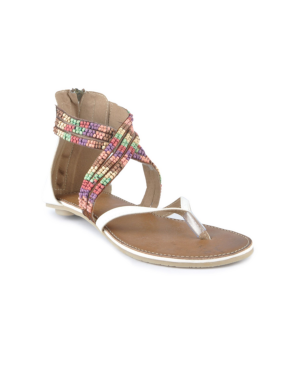

In [84]:
import random
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

sample_file = random.choice(list(Path(IMAGE_DIR).glob("*.jpg")))

img = Image.open(sample_file)

print(sample_file.name)
print(img.size)

plt.imshow(img)
plt.axis("off")
plt.show()

In [1]:
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("CLIP ready")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 52917.42it/s]


CLIP ready


In [5]:
from PIL import Image
import torch
import numpy as np
from pathlib import Path


In [12]:
from pathlib import Path

img_dir = Path("../data/product_images")
all_images = list(img_dir.glob("*"))

print("total images:", len(all_images))

first_img = all_images[0]
print(first_img)

from PIL import Image

image = Image.open(first_img).convert("RGB")
print(image.size)



total images: 100
../data/product_images/11229.jpg
(1800, 2400)


In [13]:
inputs = clip_processor(images=image, return_tensors="pt")

print(inputs.keys())
print(inputs["pixel_values"].shape)

KeysView({'pixel_values': tensor([[[[1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
          [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
          [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
          ...,
          [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
          [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
          [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303]],

         [[2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
          [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
          [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
          ...,
          [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
          [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
          [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749]],

         [[2.1459, 2.1459, 2.1459,  ..., 2.1459, 2.1459, 2.1459],
          [2.1459, 2.1459, 2.1459,  ..., 2.1459, 2.1459, 2.1459],
          [2.145

In [15]:
with torch.no_grad():
    image_features = clip_model.get_image_features(**inputs)

type(image_features)
print(image_features)

BaseModelOutputWithPooling(last_hidden_state=tensor([[[ 0.5908,  0.2204,  0.2012,  ..., -0.2475, -0.0080, -0.3080],
         [-0.1783,  0.2961, -0.3371,  ...,  0.0261,  0.3470,  0.1407],
         [ 0.3720,  0.5776, -0.0760,  ...,  0.2548,  0.4964, -0.1972],
         ...,
         [ 0.0969,  0.5981,  0.0610,  ...,  0.4874,  0.3024,  0.1207],
         [-0.1654,  0.5425, -0.2981,  ..., -0.0720,  0.2738, -0.1850],
         [-0.1592,  0.3750, -0.4268,  ..., -0.0075,  0.1660,  0.0889]]]), pooler_output=tensor([[-1.9751e-01,  4.4319e-02, -6.9911e-02,  1.6216e-03,  7.1037e-02,
          1.4129e-01, -5.7209e-02,  5.7136e-02, -1.0358e-01,  2.6501e-01,
          3.4395e-01, -2.2078e-01,  1.5398e-02, -4.6458e-01, -2.6288e-01,
         -2.1003e-02,  6.9632e-02,  2.1091e-01, -2.9067e-01, -4.0309e-01,
         -5.7159e-01, -3.7299e-01, -2.9617e-01, -2.5735e-01,  1.0425e-01,
          2.4135e-01, -4.4124e-01, -3.3227e-01,  1.8187e-01, -2.2826e-01,
          3.5081e-01,  4.1454e-01,  7.6232e-03, -8.520

In [18]:
with torch.no_grad():
    output = clip_model.get_image_features(**inputs)

print(type(output))
print(output.keys())

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
odict_keys(['last_hidden_state', 'pooler_output'])


In [20]:
with torch.no_grad():
    output = clip_model.get_image_features(**inputs)

image_embedding = output.pooler_output

print(image_embedding.shape)
print(image_embedding[:1, :10])

torch.Size([1, 512])
tensor([[-0.1975,  0.0443, -0.0699,  0.0016,  0.0710,  0.1413, -0.0572,  0.0571,
         -0.1036,  0.2650]])


In [22]:
image_embedding = image_embedding / image_embedding.norm(dim=-1, keepdim=True)

print(image_embedding.shape)
print(torch.norm(image_embedding, dim=-1))
print(image_embedding[:1, :10])

torch.Size([1, 512])
tensor([1.])
tensor([[-0.0194,  0.0044, -0.0069,  0.0002,  0.0070,  0.0139, -0.0056,  0.0056,
         -0.0102,  0.0260]])


In [24]:
image_embedding_np = image_embedding.cpu().numpy()[0]

print(type(image_embedding_np))
print(image_embedding_np.shape)
print(image_embedding_np[:10])

<class 'numpy.ndarray'>
(512,)
[-0.0193894   0.0043508  -0.00686319  0.00015919  0.0069737   0.01387
 -0.00561622  0.00560899 -0.0101689   0.02601564]


In [26]:
sample_row = {
    "image_path": str(first_img),
    "image_embedding": image_embedding_np
}

print(sample_row["image_path"])
print(sample_row["image_embedding"].shape)

../data/product_images/11229.jpg
(512,)


In [28]:
second_img = all_images[1]

image2 = Image.open(second_img).convert("RGB")
inputs2 = clip_processor(images=image2, return_tensors="pt")

with torch.no_grad():
    output2 = clip_model.get_image_features(**inputs2)

image_embedding2 = output2.pooler_output
image_embedding2 = image_embedding2 / image_embedding2.norm(dim=-1, keepdim=True)
image_embedding2 = image_embedding2.cpu().numpy()[0]

similarity = np.dot(image_embedding_np, image_embedding2)

print("first:", first_img.name)
print("second:", second_img.name)
print("similarity:", similarity)

first: 11229.jpg
second: 54629.jpg
similarity: 0.7661439


In [30]:
third_img = all_images[20]

image3 = Image.open(third_img).convert("RGB")
inputs3 = clip_processor(images=image3, return_tensors="pt")

with torch.no_grad():
    output3 = clip_model.get_image_features(**inputs3)

image_embedding3 = output3.pooler_output
image_embedding3 = image_embedding3 / image_embedding3.norm(dim=-1, keepdim=True)
image_embedding3 = image_embedding3.cpu().numpy()[0]

similarity_3 = np.dot(image_embedding_np, image_embedding3)

print("first:", first_img.name)
print("third:", third_img.name)
print("similarity:", similarity_3)

first: 11229.jpg
third: 7241.jpg
similarity: 0.6302625


In [32]:
image_embeddings = {}

for img_path in all_images:
    image = Image.open(img_path).convert("RGB")
    inputs = clip_processor(images=image, return_tensors="pt")

    with torch.no_grad():
        output = clip_model.get_image_features(**inputs)

    emb = output.pooler_output
    emb = emb / emb.norm(dim=-1, keepdim=True)
    emb = emb.cpu().numpy()[0]

    image_embeddings[img_path.name] = emb

print("done:", len(image_embeddings))
print("one vector shape:", image_embeddings[first_img.name].shape)

done: 100
one vector shape: (512,)


In [40]:
image_names = list(image_embeddings.keys())

image_matrix = np.vstack([
    image_embeddings[name]
    for name in image_names
])




In [36]:
query_vector = image_embeddings[first_img.name]

scores = image_matrix @ query_vector

top_idx = scores.argsort()[::-1][:5]

for i in top_idx:
    print(image_names[i], scores[i])
    

11229.jpg 1.0
31844.jpg 0.8017051
10705.jpg 0.79725355
51639.jpg 0.7778293
45121.jpg 0.7764324


In [41]:
import pandas as pd

premium_df = pd.read_parquet("../data/premium_catalog.parquet")

print(premium_df.shape)
print(premium_df.columns.tolist())

(3000, 21)
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'link', 'color_score', 'category_score', 'luxury_score', 'brand', 'embedding_text', 'text_embedding', 'clean_embedding_text', 'final_embedding_text', 'new_text_embedding', 'luxury_score_norm']


In [43]:
premium_df[premium_df["id"] == 11229][
    ["id", "productDisplayName"]
]

,id,productDisplayName
7419,11229,Esprit Women Cine Citta Silver Watches


In [45]:
embedding_rows = []

for filename, emb in image_embeddings.items():
    product_id = int(filename.replace(".jpg", ""))

    embedding_rows.append({
        "id": product_id,
        "image_embedding": emb
    })

image_df = pd.DataFrame(embedding_rows)

print(image_df.shape)
image_df.head()


(100, 2)


,id,image_embedding
0,11229,"[-0.019389397, 0.0043507963, -0.0068631847, 0...."
1,54629,"[0.030683275, -0.023558756, 0.016009953, -0.05..."
2,12480,"[-0.028143287, 0.006578449, 0.028600652, 0.010..."
3,50894,"[-0.0017550074, 0.03898324, 0.0014899557, 0.03..."
4,56942,"[-0.002470348, -0.042785317, 0.022570483, 0.03..."


In [47]:
premium_with_images = premium_df.merge(
    image_df,
    on="id",
    how="left"
)

print(premium_with_images.shape)

premium_with_images[
    ["id", "productDisplayName", "image_embedding"]
].head()

(3000, 22)


,id,productDisplayName,image_embedding
0,33903,Citizen Men White Dial Watch,"[0.009897561, -0.012278214, 0.05044221, -0.031..."
1,39027,CASIO ENTICER Men Black Dial Watch A641,"[0.026326202, -0.028771522, 0.014516459, -0.01..."
2,31844,Titan Women Grey Dial Watch,"[-0.018896779, -0.0038603193, 0.017717287, -0...."
3,45141,Casio Enticer Men Black Analogue Watch MTP-129...,"[0.054780424, -0.049273, 0.01281875, -0.058313..."
4,46596,Catwalk Women Olive Sandals,"[-0.022558426, -0.034455556, 0.008926841, 0.00..."


In [48]:
premium_with_images["image_embedding"].notna().sum()

np.int64(100)

In [49]:
coverage = (
    premium_with_images["image_embedding"]
    .notna()
    .mean()
)

print("coverage:", coverage)

coverage: 0.03333333333333333


In [51]:
premium_df["link"].notna().sum()

np.int64(3000)

In [52]:
premium_df["link"].head(5).tolist()

['http://assets.myntassets.com/v1/images/style/properties/015be75a6fbcb92b2fa26e94db850bd0_images.jpg',
 'http://assets.myntassets.com/v1/images/style/properties/Casio-Men-Black-Watch_5e24bacdae2fd71f14df879b002048dd_images.jpg',
 'http://assets.myntassets.com/v1/images/style/properties/0d9a0e8e1a60b50c74f82e4b70186a1c_images.jpg',
 'http://assets.myntassets.com/v1/images/style/properties/Casio-Men-Black-Dial-Watch_c68feb461804e88c46ac5e5d82d015f6_images.jpg',
 'http://assets.myntassets.com/v1/images/style/properties/3747ca1e0c35f26c1602707c759cc2af_images.jpg']

In [53]:
import os

downloaded_ids = {
    int(f.replace(".jpg", ""))
    for f in os.listdir("../data/product_images")
    if f.endswith(".jpg")
}

print("downloaded:", len(downloaded_ids))

remaining_df = premium_df[
    ~premium_df["id"].isin(downloaded_ids)
]

print("remaining:", len(remaining_df))

downloaded: 100
remaining: 2900


In [55]:
remaining_df[["id", "link"]].head(3)

,id,link
3996,11498,http://assets.myntassets.com/v1/images/style/p...
17514,51546,http://assets.myntassets.com/v1/images/style/p...
17516,54808,http://assets.myntassets.com/v1/images/style/p...


In [56]:
import requests
from pathlib import Path
from tqdm import tqdm

img_dir = Path("../data/product_images")
img_dir.mkdir(exist_ok=True)

downloaded = 0
failed = 0

for _, row in tqdm(remaining_df.iterrows(), total=len(remaining_df)):
    pid = row["id"]
    url = row["link"]

    save_path = img_dir / f"{pid}.jpg"

    if save_path.exists():
        continue

    try:
        r = requests.get(url, timeout=15)

        if r.status_code == 200:
            with open(save_path, "wb") as f:
                f.write(r.content)
            downloaded += 1
        else:
            failed += 1

    except:
        failed += 1

print("downloaded:", downloaded)
print("failed:", failed)

100%|██████████| 2900/2900 [13:18<00:00,  3.63it/s] 

downloaded: 2899
failed: 1


In [57]:
import os

all_images = [
    f for f in os.listdir("../data/product_images")
    if f.endswith(".jpg")
]

print(len(all_images))

2999


In [ ]:
from PIL import Image
import numpy as np
import torch
from tqdm import tqdm
from pathlib import Path

all_image_paths = list(Path("../data/product_images").glob("*.jpg"))

len(all_image_paths)

In [60]:
image_embeddings = {}

for img_path in tqdm(all_image_paths):
    image = Image.open(img_path).convert("RGB")
    inputs = clip_processor(images=image, return_tensors="pt")

    with torch.no_grad():
        output = clip_model.get_image_features(**inputs)

    emb = output.pooler_output
    emb = emb / emb.norm(dim=-1, keepdim=True)
    emb = emb.cpu().numpy()[0]

    image_embeddings[img_path.name] = emb

print("done:", len(image_embeddings))

100%|██████████| 2999/2999 [02:16<00:00, 21.96it/s]

done: 2999


In [4]:
print(len(image_embeddings))

NameError: name 'image_embeddings' is not defined

In [ ]:
import os

os.listdir("../data")[:20]



['.DS_Store',
 'images.csv',
 'catalog_with_embeddings.parquet',
 'product_images',
 'catalog_with_embeddings.pkl',
 'premium_catalog.parquet',
 'styles.csv']

In [11]:
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("CLIP ready")




Loading weights: 100%|██████████| 398/398 [00:00<00:00, 64380.92it/s]


CLIP ready


In [12]:
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import torch
import numpy as np
import pandas as pd

all_image_paths = list(Path("../data/product_images").glob("*.jpg"))

image_embeddings = {}

for img_path in tqdm(all_image_paths):
    image = Image.open(img_path).convert("RGB")
    inputs = clip_processor(images=image, return_tensors="pt")

    with torch.no_grad():
        output = clip_model.get_image_features(**inputs)

    emb = output.pooler_output
    emb = emb / emb.norm(dim=-1, keepdim=True)
    emb = emb.cpu().numpy()[0]

    image_embeddings[img_path.name] = emb

embedding_rows = []

for filename, emb in image_embeddings.items():
    product_id = int(filename.replace(".jpg", ""))

    embedding_rows.append({
        "id": product_id,
        "image_embedding": emb
    })

image_df = pd.DataFrame(embedding_rows)

image_df.to_pickle("../data/image_embeddings.pkl")

print(image_df.shape)

100%|██████████| 2999/2999 [02:16<00:00, 21.98it/s]


(2999, 2)


In [14]:
premium_df = pd.read_parquet("../data/premium_catalog.parquet")

image_df = pd.read_pickle("../data/image_embeddings.pkl")

premium_with_images = premium_df.merge(
    image_df,
    on="id",
    how="left"
)

print(premium_with_images.shape)

premium_with_images[
    ["id", "productDisplayName", "image_embedding"]
].head()

(3000, 22)


,id,productDisplayName,image_embedding
0,33903,Citizen Men White Dial Watch,"[0.009897561, -0.012278214, 0.05044221, -0.031..."
1,39027,CASIO ENTICER Men Black Dial Watch A641,"[0.026326202, -0.028771522, 0.014516459, -0.01..."
2,31844,Titan Women Grey Dial Watch,"[-0.018896779, -0.0038603193, 0.017717287, -0...."
3,45141,Casio Enticer Men Black Analogue Watch MTP-129...,"[0.054780424, -0.049273, 0.01281875, -0.058313..."
4,46596,Catwalk Women Olive Sandals,"[-0.022558426, -0.034455556, 0.008926841, 0.00..."


In [15]:
premium_with_images.to_parquet(
    "../data/premium_multimodal_catalog.parquet",
    index=False
)

print("saved")

saved


In [17]:
premium_with_images = pd.read_parquet(
    "../data/premium_multimodal_catalog.parquet"
)

premium_with_images.shape

(3000, 22)

In [22]:
premium_with_images["image_embedding"].apply(
    lambda x: len(x) if isinstance(x, np.ndarray) else None
).value_counts()



image_embedding
512.0    2999
Name: count, dtype: int64

In [23]:
valid_df = premium_with_images[
    premium_with_images["image_embedding"].notna()
].copy()

image_matrix = np.vstack(
    valid_df["image_embedding"].values
)

print(valid_df.shape)
print(image_matrix.shape)

(2999, 22)
(2999, 512)


In [25]:
query = "minimal luxury silver watch"

inputs = clip_processor(
    text=[query],
    return_tensors="pt",
    padding=True
)

with torch.no_grad():
    text_output = clip_model.get_text_features(**inputs)

text_embedding = text_output.pooler_output

text_embedding = text_embedding / text_embedding.norm(
    dim=-1,
    keepdim=True
)

print(text_embedding.shape)

torch.Size([1, 512])


In [26]:
text_embedding = text_embedding.cpu().numpy()[0]

print(type(text_embedding))
print(text_embedding.shape)

<class 'numpy.ndarray'>
(512,)


In [27]:
scores = image_matrix @ text_embedding

print(scores.shape)
print(scores[:10])


(2999,)
[0.2564769  0.27018005 0.3191735  0.2490772  0.13885799 0.27511942
 0.2050149  0.17811266 0.28509235 0.17529969]


In [28]:
top_idx = scores.argsort()[::-1][:10]

top_results = valid_df.iloc[top_idx][
    ["productDisplayName", "articleType", "baseColour"]
]

top_results

,productDisplayName,articleType,baseColour
1499,Fastrack Women Black Dial Watch,Watches,Black
2081,Fastrack Women White Dial Watch N2298SM01,Watches,White
2605,Fastrack Women Black & Grey Dial Watch N2161SL06,Watches,Black
514,Fastrack Women Black Dial Watch N2298sm03,Watches,Black
2410,Titan Men Black Dial Watch,Watches,Black
584,Citizen Women Black Dial Watch,Watches,Black
1999,Fastrack Women Silver-Toned Dial Watch NA6001SM01,Watches,Silver
197,Casio Enticer Women White Dial Watch LTP-1165A...,Watches,White
1155,Fastrack Women White Dial Watch N2166SM01,Watches,White
891,Timex Women Black Dial Watch,Watches,Black


In [30]:
valid_df = valid_df.copy()

valid_df["clip_score"] = scores

valid_df[
    ["productDisplayName", "clip_score"]
].head()


,productDisplayName,clip_score
0,Citizen Men White Dial Watch,0.256477
1,CASIO ENTICER Men Black Dial Watch A641,0.270180
2,Titan Women Grey Dial Watch,0.319174
3,Casio Enticer Men Black Analogue Watch MTP-129...,0.249077
4,Catwalk Women Olive Sandals,0.138858


In [32]:
clip_scores = valid_df["clip_score"].values

clip_scores_norm = (
    clip_scores - clip_scores.min()
) / (
    clip_scores.max() - clip_scores.min()
)

valid_df["clip_score_norm"] = clip_scores_norm

valid_df[
    ["productDisplayName", "clip_score_norm"]
].head()

,productDisplayName,clip_score_norm
0,Citizen Men White Dial Watch,0.692755
1,CASIO ENTICER Men Black Dial Watch A641,0.747167
2,Titan Women Grey Dial Watch,0.941705
3,Casio Enticer Men Black Analogue Watch MTP-129...,0.663373
4,Catwalk Women Olive Sandals,0.225725


In [34]:
valid_df["final_score"] = (
    0.75 * valid_df["clip_score_norm"]
    +
    0.25 * valid_df["luxury_score_norm"]
)

top_results = valid_df.sort_values(
    "final_score",
    ascending=False
)[
    [
        "productDisplayName",
        "articleType",
        "baseColour",
        "clip_score_norm",
        "luxury_score_norm",
        "final_score"
    ]
].head(10)

top_results

,productDisplayName,articleType,baseColour,clip_score_norm,luxury_score_norm,final_score
1499,Fastrack Women Black Dial Watch,Watches,Black,1.000000,1.0,1.000000
2081,Fastrack Women White Dial Watch N2298SM01,Watches,White,0.985737,1.0,0.989303
2605,Fastrack Women Black & Grey Dial Watch N2161SL06,Watches,Black,0.970747,1.0,0.978061
514,Fastrack Women Black Dial Watch N2298sm03,Watches,Black,0.967623,1.0,0.975717
2410,Titan Men Black Dial Watch,Watches,Black,0.964441,1.0,0.973331
584,Citizen Women Black Dial Watch,Watches,Black,0.957513,1.0,0.968135
1999,Fastrack Women Silver-Toned Dial Watch NA6001SM01,Watches,Silver,0.956744,1.0,0.967558
197,Casio Enticer Women White Dial Watch LTP-1165A...,Watches,White,0.955150,1.0,0.966363
1155,Fastrack Women White Dial Watch N2166SM01,Watches,White,0.953248,1.0,0.964936
891,Timex Women Black Dial Watch,Watches,Black,0.949755,1.0,0.962317


In [36]:
type(premium_with_images["new_text_embedding"].iloc[0])

numpy.ndarray

In [38]:
text_matrix = np.vstack(
    premium_with_images["new_text_embedding"].values
)

print(text_matrix.shape)

(3000, 384)


In [40]:
from sentence_transformers import SentenceTransformer

In [41]:
semantic_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("semantic model ready")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8567.61it/s]


semantic model ready


In [42]:
query = "minimal luxury silver watch"

semantic_query_embedding = semantic_model.encode(
    query,
    normalize_embeddings=True
)

print(type(semantic_query_embedding))
print(semantic_query_embedding.shape)

<class 'numpy.ndarray'>
(384,)


In [43]:
semantic_scores = (
    text_matrix @ semantic_query_embedding
)

print(semantic_scores.shape)
print(semantic_scores[:10])

(3000,)
[0.3436635  0.3732163  0.4299544  0.503911   0.13783461 0.5921296
 0.36187074 0.2852053  0.40144604 0.12232944]


In [45]:
premium_with_images["semantic_score"] = semantic_scores

premium_with_images[
    ["productDisplayName", "semantic_score"]
].head()

,productDisplayName,semantic_score
0,Citizen Men White Dial Watch,0.343664
1,CASIO ENTICER Men Black Dial Watch A641,0.373216
2,Titan Women Grey Dial Watch,0.429954
3,Casio Enticer Men Black Analogue Watch MTP-129...,0.503911
4,Catwalk Women Olive Sandals,0.137835


In [46]:
semantic_scores = premium_with_images[
    "semantic_score"
].values

semantic_scores_norm = (
    semantic_scores - semantic_scores.min()
) / (
    semantic_scores.max() - semantic_scores.min()
)

premium_with_images[
    "semantic_score_norm"
] = semantic_scores_norm

premium_with_images[
    ["productDisplayName", "semantic_score_norm"]
].head()

,productDisplayName,semantic_score_norm
0,Citizen Men White Dial Watch,0.513771
1,CASIO ENTICER Men Black Dial Watch A641,0.556138
2,Titan Women Grey Dial Watch,0.637478
3,Casio Enticer Men Black Analogue Watch MTP-129...,0.743503
4,Catwalk Women Olive Sandals,0.218693


In [52]:
premium_with_images.loc[
    valid_df.index,
    "clip_score_norm"
] = valid_df["clip_score_norm"]

premium_with_images["clip_score_norm"] = (
    premium_with_images["clip_score_norm"]
    .fillna(0)
)

premium_with_images["final_score"] = (
    0.50 * premium_with_images["semantic_score_norm"]
    +
    0.35 * premium_with_images["clip_score_norm"]
    +
    0.15 * premium_with_images["luxury_score_norm"]
)

top_results = premium_with_images.sort_values(
    "final_score",
    ascending=False
)[
    [
        "productDisplayName",
        "articleType",
        "baseColour",
        "semantic_score_norm",
        "clip_score_norm",
        "luxury_score_norm",
        "final_score"
    ]
].head(10)

top_results

,productDisplayName,articleType,baseColour,semantic_score_norm,clip_score_norm,luxury_score_norm,final_score
1319,CASIO Enticer Women Silver Analogue Watch LTP-...,Watches,Black,0.935046,0.946772,1.0,0.948893
1288,Miss Sixty Silver Dial Watch,Watches,Silver,0.938752,0.924724,1.0,0.943029
1855,Miss Sixty Silver Dial Watch,Watches,Silver,0.938752,0.903942,1.0,0.935756
1656,Casio Enticer Men Silver Analogue Watch MTP-11...,Watches,Silver,0.914287,0.933119,1.0,0.933735
1682,Miss Sixty Silver Watch,Watches,Silver,1.000000,0.805410,1.0,0.931893
1999,Fastrack Women Silver-Toned Dial Watch NA6001SM01,Watches,Silver,0.878517,0.956744,1.0,0.924119
704,Fastrack Women Silver-Toned Dial Watch NA2404sm01,Watches,Silver,0.873415,0.945895,1.0,0.917771
1013,Casio Enticer Men Silver Analogue Watch MTP-13...,Watches,White,0.891834,0.903484,1.0,0.912137
2226,Titan Women Silver Watch,Watches,Silver,0.904381,0.884151,1.0,0.911643
863,Casio Enticer Men Silver Analogue Watch MTP-13...,Watches,Silver,0.928532,0.842568,1.0,0.909165


In [54]:
def get_semantic_embedding(query):
    embedding = semantic_model.encode(
        query,
        normalize_embeddings=True
    )

    return embedding

In [56]:
query_vec = get_semantic_embedding(
    "minimal luxury silver watch"
)

print(type(query_vec))
print(query_vec.shape)

<class 'numpy.ndarray'>
(384,)


In [105]:
def get_clip_text_embedding(query):

    inputs = clip_processor(
        text=[query],
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        output = clip_model.get_text_features(
            **inputs
        )

    embedding = output.pooler_output

    embedding = embedding / embedding.norm(
        dim=-1,
        keepdim=True
    )

    embedding = embedding.cpu().numpy()[0]

    return embedding

In [59]:
clip_vec = get_clip_text_embedding(
    "minimal luxury silver watch"
)

print(type(clip_vec))
print(clip_vec.shape)

<class 'numpy.ndarray'>
(512,)


In [61]:
def get_semantic_scores(query):

    query_embedding = get_semantic_embedding(
        query
    )

    scores = (
        text_matrix @ query_embedding
    )

    return scores

In [63]:
scores = get_semantic_scores(
    "minimal luxury silver watch"
)

print(type(scores))
print(scores.shape)
print(scores[:5])

<class 'numpy.ndarray'>
(3000,)
[0.3436635  0.3732163  0.4299544  0.503911   0.13783461]


In [65]:
def get_clip_scores(query):

    query_embedding = get_clip_text_embedding(
        query
    )

    scores = (
        image_matrix @ query_embedding
    )

    return scores

In [67]:
clip_scores = get_clip_scores(
    "minimal luxury silver watch"
)

print(type(clip_scores))
print(clip_scores.shape)
print(clip_scores[:5])

<class 'numpy.ndarray'>
(2999,)
[0.2564769  0.27018005 0.3191735  0.2490772  0.13885799]


In [69]:
def normalize_scores(scores):

    normalized = (
        scores - scores.min()
    ) / (
        scores.max() - scores.min()
    )

    return normalized

In [71]:
norm_scores = normalize_scores(
    clip_scores
)

print(norm_scores[:5])
print(norm_scores.min())
print(norm_scores.max())

[0.6927554  0.7471665  0.94170517 0.6633733  0.22572528]
0.0
1.0


In [123]:
def search_products(
query,
    gender=None,
    top_k=10,
    semantic_weight=0.6,
    clip_weight=0.4
):

    semantic_query = get_semantic_embedding(
        query
    )

    semantic_scores = (
    text_matrix @ semantic_query
    )

    semantic_scores = normalize_scores(
        semantic_scores
    )

    clip_scores = get_clip_scores(
        query
    )

    clip_scores = normalize_scores(
        clip_scores
    )

    temp_df = df.copy()

    temp_df["semantic_score"] = semantic_scores

    temp_df["clip_score"] = clip_scores

    temp_df["final_score"] = (
        semantic_weight * temp_df["semantic_score"]
+
clip_weight * temp_df["clip_score"]
    )

    if gender is not None:
        temp_df = temp_df[
            temp_df["gender"] == gender
        ]

    query_lower = query.lower()

    if (
        "outfit" in query_lower
        or "wedding" in query_lower
        or "beach" in query_lower
        or "summer" in query_lower
    ):

        allowed_categories = [
            "Shirts",
            "Trousers",
            "Casual Shoes",
            "Sandals",
            "Kurtas",
            "Blazers"
        ]

        temp_df = temp_df[
            temp_df["articleType"].isin(
                allowed_categories
            )
        ]

    results = temp_df.sort_values(
        "final_score",
        ascending=False
    )[
        [
            "productDisplayName",
            "gender",
            "articleType",
            "baseColour",
            "final_score"
        ]
    ].head(top_k)

    return results

In [92]:
valid_df["articleType"].value_counts().head(30)

articleType
Watches         1197
Handbags         578
Heels            511
Formal Shoes     407
Dresses          157
Clutches          80
Sarees            69
Name: count, dtype: int64

In [94]:
premium_df = pd.read_pickle(
    "../data/catalog_with_embeddings.pkl"
)

print(premium_df.shape)

(23644, 17)


In [96]:
premium_df["articleType"].value_counts().head(30)

articleType
Shirts          3217
Casual Shoes    2845
Watches         2542
Kurtas          1844
Tops            1762
Handbags        1757
Heels           1323
Sunglasses      1073
Wallets          935
Sandals          897
Belts            813
Formal Shoes     637
Jeans            609
Trousers         530
Flats            500
Dresses          464
Sarees           427
Earrings         416
Clutches         289
Sweaters         277
Jackets          258
Tunics           229
Name: count, dtype: int64

In [98]:
target_categories = [
    "Shirts",
    "Casual Shoes",
    "Watches",
    "Kurtas",
    "Handbags",
    "Sandals",
    "Formal Shoes",
    "Jeans",
    "Trousers",
    "Jackets"
]

balanced_df = premium_df[
    premium_df["articleType"].isin(
        target_categories
    )
].copy()

print(balanced_df.shape)

balanced_df["articleType"].value_counts()

(15136, 17)


articleType
Shirts          3217
Casual Shoes    2845
Watches         2542
Kurtas          1844
Handbags        1757
Sandals          897
Formal Shoes     637
Jeans            609
Trousers         530
Jackets          258
Name: count, dtype: int64

In [101]:
balanced_sampled_df = (
    balanced_df
    .groupby("articleType")
    .sample(
        n=500,
        replace=True,
        random_state=42
    )
    .reset_index(drop=True)
)

print(balanced_sampled_df.shape)

print(
    balanced_sampled_df["articleType"]
    .value_counts()
)

(5000, 17)
articleType
Casual Shoes    500
Formal Shoes    500
Handbags        500
Jackets         500
Jeans           500
Kurtas          500
Sandals         500
Shirts          500
Trousers        500
Watches         500
Name: count, dtype: int64


In [103]:
from pathlib import Path

existing_images = set(
    [
        p.stem
        for p in Path(
            "../data/product_images"
        ).glob("*.jpg")
    ]
)

balanced_sampled_df["has_image"] = (
    balanced_sampled_df["id"]
    .astype(str)
    .isin(existing_images)
)

print(
    balanced_sampled_df["has_image"]
    .value_counts()
)

has_image
False    4287
True      713
Name: count, dtype: int64


In [104]:
remaining_df = balanced_sampled_df[
    balanced_sampled_df["has_image"] == False
].copy()

print(remaining_df.shape)

remaining_df[
    ["id", "articleType", "link"]
].head()


(4287, 18)


,id,articleType,link
0,7407,Casual Shoes,http://assets.myntassets.com/v1/images/style/p...
1,8996,Casual Shoes,http://assets.myntassets.com/v1/images/style/p...
2,37253,Casual Shoes,http://assets.myntassets.com/v1/images/style/p...
3,2498,Casual Shoes,http://assets.myntassets.com/v1/images/style/p...
4,22102,Casual Shoes,http://assets.myntassets.com/v1/images/style/p...


In [105]:
import requests
from pathlib import Path
from tqdm import tqdm

save_dir = Path("../data/product_images")

downloaded = 0
failed = 0

for _, row in tqdm(
    remaining_df.iterrows(),
    total=len(remaining_df)
):

    product_id = row["id"]

    image_url = row["link"]

    save_path = save_dir / f"{product_id}.jpg"

    try:

        response = requests.get(
            image_url,
            timeout=10
        )

        if response.status_code == 200:

            with open(save_path, "wb") as f:
                f.write(response.content)

            downloaded += 1

        else:
            failed += 1

    except:
        failed += 1

print("downloaded:", downloaded)
print("failed:", failed)

100%|██████████| 4287/4287 [21:03<00:00,  3.39it/s]

downloaded: 4287
failed: 0


In [106]:
from pathlib import Path

balanced_image_paths = []

for product_id in balanced_sampled_df["id"]:

    img_path = Path(
        f"../data/product_images/{product_id}.jpg"
    )

    if img_path.exists():

        balanced_image_paths.append(img_path)

print(len(balanced_image_paths))
print(balanced_image_paths[:3])

5000
[PosixPath('../data/product_images/7407.jpg'), PosixPath('../data/product_images/8996.jpg'), PosixPath('../data/product_images/37253.jpg')]


In [107]:
from PIL import Image
from tqdm import tqdm

balanced_image_embeddings = {}

for img_path in tqdm(balanced_image_paths):

    image = Image.open(img_path).convert("RGB")

    inputs = clip_processor(
        images=image,
        return_tensors="pt"
    )

    with torch.no_grad():

        output = clip_model.get_image_features(
            **inputs
        )

    emb = output.pooler_output

    emb = emb / emb.norm(
        dim=-1,
        keepdim=True
    )

    emb = emb.cpu().numpy()[0]

    balanced_image_embeddings[
        img_path.name
    ] = emb

print(
    "done:",
    len(balanced_image_embeddings)
)

100%|██████████| 5000/5000 [04:00<00:00, 20.80it/s]

done: 3826


In [109]:
balanced_sampled_df["id"].nunique()

3826

In [115]:
balanced_sampled_df = (
    balanced_df
    .groupby("articleType", group_keys=False)
    .apply(
        lambda x: x.sample(
            n=min(500, len(x)),
            replace=False,
            random_state=42
        )
    )
)

balanced_sampled_df = balanced_sampled_df.reset_index()

print(balanced_sampled_df.shape)

print(
    balanced_sampled_df["id"].nunique()
)

print(
    balanced_sampled_df["articleType"]
    .value_counts()
)

(4758, 17)
4758


KeyError: 'articleType'

In [117]:
print(balanced_sampled_df.columns)

Index(['index', 'id', 'gender', 'masterCategory', 'subCategory', 'baseColour',
       'season', 'year', 'usage', 'productDisplayName', 'link', 'color_score',
       'category_score', 'luxury_score', 'brand', 'embedding_text',
       'text_embedding'],
      dtype='str')


In [120]:
target_categories = [
    "Shirts",
    "Casual Shoes",
    "Watches",
    "Kurtas",
    "Handbags",
    "Sandals",
    "Formal Shoes",
    "Jeans",
    "Trousers",
    "Jackets"
]

balanced_df = premium_df[
    premium_df["articleType"].isin(
        target_categories
    )
].copy()

print(balanced_df.columns)

balanced_sampled_df = (
    balanced_df
    .groupby("articleType", group_keys=False)
    .apply(
        lambda x: x.sample(
            n=min(500, len(x)),
            replace=False,
            random_state=42
        )
    )
    .reset_index(drop=True)
)

print(balanced_sampled_df.shape)

print(
    balanced_sampled_df["articleType"]
    .value_counts()
)

print(
    balanced_sampled_df["id"].nunique()
)

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'link',
       'color_score', 'category_score', 'luxury_score', 'brand',
       'embedding_text', 'text_embedding'],
      dtype='str')
(4758, 16)


KeyError: 'articleType'

In [122]:
sampled_parts = []

for category in target_categories:

    category_df = balanced_df[
        balanced_df["articleType"] == category
    ]

    sampled_df = category_df.sample(
        n=min(500, len(category_df)),
        replace=False,
        random_state=42
    )

    sampled_parts.append(sampled_df)

balanced_sampled_df = pd.concat(
    sampled_parts,
    ignore_index=True
)

print(balanced_sampled_df.shape)

print(
    balanced_sampled_df["articleType"]
    .value_counts()
)

print(
    balanced_sampled_df["id"].nunique()
)

(4758, 17)
articleType
Shirts          500
Casual Shoes    500
Watches         500
Kurtas          500
Handbags        500
Sandals         500
Formal Shoes    500
Jeans           500
Trousers        500
Jackets         258
Name: count, dtype: int64
4758


In [124]:
from pathlib import Path

balanced_image_paths = []

for product_id in balanced_sampled_df["id"]:

    img_path = Path(
        f"../data/product_images/{product_id}.jpg"
    )

    if img_path.exists():

        balanced_image_paths.append(
            img_path
        )

print(len(balanced_image_paths))

print(balanced_image_paths[:3])

2085
[PosixPath('../data/product_images/8851.jpg'), PosixPath('../data/product_images/11387.jpg'), PosixPath('../data/product_images/20155.jpg')]


In [125]:
existing_images = set(
    [
        p.stem
        for p in Path(
            "../data/product_images"
        ).glob("*.jpg")
    ]
)

balanced_sampled_df["has_image"] = (
    balanced_sampled_df["id"]
    .astype(str)
    .isin(existing_images)
)

print(
    balanced_sampled_df["has_image"]
    .value_counts()
)

has_image
False    2673
True     2085
Name: count, dtype: int64


In [128]:
remaining_df = balanced_sampled_df[
    balanced_sampled_df["has_image"] == False
].copy()

print(remaining_df.shape)

remaining_df[
    ["id", "articleType", "link"]
].head()

(2673, 18)


,id,articleType,link
0,8859,Shirts,http://assets.myntassets.com/v1/images/style/p...
1,18889,Shirts,http://assets.myntassets.com/v1/images/style/p...
2,8181,Shirts,http://assets.myntassets.com/v1/images/style/p...
3,5960,Shirts,http://assets.myntassets.com/v1/images/style/p...
4,13734,Shirts,http://assets.myntassets.com/v1/images/style/p...


In [129]:
import requests
from pathlib import Path
from tqdm import tqdm

save_dir = Path("../data/product_images")

downloaded = 0
failed = 0

for _, row in tqdm(
    remaining_df.iterrows(),
    total=len(remaining_df)
):

    product_id = row["id"]

    image_url = row["link"]

    save_path = save_dir / f"{product_id}.jpg"

    try:

        response = requests.get(
            image_url,
            timeout=10
        )

        if response.status_code == 200:

            with open(save_path, "wb") as f:
                f.write(response.content)

            downloaded += 1

        else:
            failed += 1

    except:
        failed += 1

print("downloaded:", downloaded)
print("failed:", failed)

100%|██████████| 2673/2673 [16:48<00:00,  2.65it/s]

downloaded: 2672
failed: 1


In [130]:
from pathlib import Path

image_dir = Path("../data/product_images")

balanced_sampled_df["image_path"] = balanced_sampled_df["id"].apply(
    lambda x: image_dir / f"{x}.jpg"
)

balanced_sampled_df["has_image"] = balanced_sampled_df["image_path"].apply(
    lambda x: x.exists()
)

print(
    balanced_sampled_df["has_image"].value_counts()
)

has_image
True     4757
False       1
Name: count, dtype: int64


In [131]:
from pathlib import Path

image_dir = Path("../data/product_images")

balanced_sampled_df["image_path"] = balanced_sampled_df["id"].apply(
    lambda x: image_dir / f"{x}.jpg"
)

balanced_sampled_df["has_image"] = balanced_sampled_df["image_path"].apply(
    lambda x: x.exists()
)

print(
    balanced_sampled_df["has_image"].value_counts()
)

has_image
True     4757
False       1
Name: count, dtype: int64


In [132]:
final_df = balanced_sampled_df[
    balanced_sampled_df["has_image"] == True
].copy()

print(final_df.shape)

(4757, 19)


In [1]:
final_df.columns.tolist()

NameError: name 'final_df' is not defined

In [2]:
NameError: name 'final_df' is not defined

SyntaxError: invalid syntax (67466381.py, line 1)

In [3]:
%whos

Interactive namespace is empty.


In [4]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', '_i2', '_i3', '_i4'])

In [5]:
import pandas as pd

df = pd.read_parquet("../data/premium_multimodal_catalog.parquet")

print(df.shape)
df.head()

(3000, 22)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,...,category_score,luxury_score,brand,embedding_text,text_embedding,clean_embedding_text,final_embedding_text,new_text_embedding,luxury_score_norm,image_embedding
0,33903,Men,Accessories,Watches,Watches,White,Summer,2017.0,Casual,Citizen Men White Dial Watch,...,3,4,Citizen,Citizen Men White Dial Watch Men Accessories W...,"[-0.003709787270054221, 0.011328279972076416, ...","Men, White, Casual, Watches","Citizen Men White Dial Watch, Men, White, Casu...","[0.023036368, -0.020229382, -0.017439736, -0.0...",1.0,"[0.009897561, -0.012278214, 0.05044221, -0.031..."
1,39027,Men,Accessories,Watches,Watches,Black,Winter,2016.0,Casual,CASIO ENTICER Men Black Dial Watch A641,...,3,4,CASIO,CASIO ENTICER Men Black Dial Watch A641 Men Ac...,"[-0.04204225912690163, -0.003717249957844615, ...","Men, Black, Casual, Watches","CASIO ENTICER Men Black Dial Watch A641, Men, ...","[-0.045497436, -0.029959666, -0.04455199, -0.0...",1.0,"[0.026326202, -0.028771522, 0.014516459, -0.01..."
2,31844,Women,Accessories,Watches,Watches,Grey,Winter,2016.0,Casual,Titan Women Grey Dial Watch,...,3,4,Titan,Titan Women Grey Dial Watch Women Accessories ...,"[-0.07692170143127441, -0.03185046836733818, 0...","Women, Grey, Casual, Watches","Titan Women Grey Dial Watch, Women, Grey, Casu...","[-0.055545162, -0.06537967, 0.0633282, -0.0116...",1.0,"[-0.018896779, -0.0038603193, 0.017717287, -0...."
3,45141,Men,Accessories,Watches,Watches,Black,Winter,2016.0,Casual,Casio Enticer Men Black Analogue Watch MTP-129...,...,3,4,Casio,Casio Enticer Men Black Analogue Watch MTP-129...,"[-0.07901513576507568, -0.002624975284561515, ...","Men, Black, Casual, Watches",Casio Enticer Men Black Analogue Watch MTP-129...,"[-0.06971148, -0.01822397, -0.011936004, 0.011...",1.0,"[0.054780424, -0.049273, 0.01281875, -0.058313..."
4,46596,Women,Footwear,Shoes,Heels,Brown,Winter,2012.0,Casual,Catwalk Women Olive Sandals,...,3,4,Catwalk,Catwalk Women Olive Sandals Women Footwear Sho...,"[-0.036130838096141815, -0.039428405463695526,...","Women, Brown, Casual, Heels","Catwalk Women Olive Sandals, Women, Brown, Cas...","[0.0044752583, -0.050251774, 0.060239468, 0.02...",1.0,"[-0.022558426, -0.034455556, 0.008926841, 0.00..."


In [6]:
df.columns.tolist()

['id',
 'gender',
 'masterCategory',
 'subCategory',
 'articleType',
 'baseColour',
 'season',
 'year',
 'usage',
 'productDisplayName',
 'link',
 'color_score',
 'category_score',
 'luxury_score',
 'brand',
 'embedding_text',
 'text_embedding',
 'clean_embedding_text',
 'final_embedding_text',
 'new_text_embedding',
 'luxury_score_norm',
 'image_embedding']

In [7]:
print(df.shape)

(3000, 22)


In [8]:
df[[
    "productDisplayName",
    "luxury_score",
    "new_text_embedding",
    "image_embedding"
]].head(3)

,productDisplayName,luxury_score,new_text_embedding,image_embedding
0,Citizen Men White Dial Watch,4,"[0.023036368, -0.020229382, -0.017439736, -0.0...","[0.009897561, -0.012278214, 0.05044221, -0.031..."
1,CASIO ENTICER Men Black Dial Watch A641,4,"[-0.045497436, -0.029959666, -0.04455199, -0.0...","[0.026326202, -0.028771522, 0.014516459, -0.01..."
2,Titan Women Grey Dial Watch,4,"[-0.055545162, -0.06537967, 0.0633282, -0.0116...","[-0.018896779, -0.0038603193, 0.017717287, -0...."


In [9]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9605.63it/s]


In [10]:
len(df["new_text_embedding"].iloc[0])

384

In [11]:
len(df["new_text_embedding"].iloc[0])


384

In [12]:
import numpy as np

# Convert all embeddings into a matrix
text_matrix = np.vstack(df["new_text_embedding"].values)

print(text_matrix.shape)

(3000, 384)


In [13]:
text_matrix.shape

(3000, 384)

In [14]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

query = "premium navy men's shirt"

query_embedding = model.encode(query, normalize_embeddings=True)

scores = text_matrix @ query_embedding

top_idx = np.argsort(scores)[::-1][:10]

df.iloc[top_idx][[
    "productDisplayName",
    "articleType",
    "baseColour",
    "brand",
    "luxury_score"
]]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7381.56it/s]


,productDisplayName,articleType,baseColour,brand,luxury_score
703,Maxima Men Navy Blue Attivo Watch,Watches,Navy Blue,Maxima,4
2187,Stoln Women Navy Blue Handbag,Handbags,Navy Blue,Stoln,4
2341,OTLS Navy Tote Bag,Handbags,Navy Blue,OTLS,4
1251,Prafful Navy Georgette Printed Saree,Sarees,Navy Blue,Prafful,4
789,Prafful Navy Crepe Printed Saree,Sarees,Navy Blue,Prafful,4
2541,Prafful Navy Crepe Printed Saree,Sarees,Navy Blue,Prafful,4
591,Pieces Women Navy Blue Purse,Clutches,Navy Blue,Pieces,4
1608,Pieces Women Navy Blue Zaki Handbag,Handbags,Navy Blue,Pieces,4
1354,Lino Perros Women Sporty Navy Blue Handbag,Handbags,Navy Blue,Lino,4
1850,Prafful Navy & Brown Georgette Printed Saree,Sarees,Navy Blue,Prafful,4


In [15]:
df[[
    "productDisplayName",
    "final_embedding_text"
]].head(5)

,productDisplayName,final_embedding_text
0,Citizen Men White Dial Watch,"Citizen Men White Dial Watch, Men, White, Casu..."
1,CASIO ENTICER Men Black Dial Watch A641,"CASIO ENTICER Men Black Dial Watch A641, Men, ..."
2,Titan Women Grey Dial Watch,"Titan Women Grey Dial Watch, Women, Grey, Casu..."
3,Casio Enticer Men Black Analogue Watch MTP-129...,Casio Enticer Men Black Analogue Watch MTP-129...
4,Catwalk Women Olive Sandals,"Catwalk Women Olive Sandals, Women, Brown, Cas..."


In [16]:
from rank_bm25 import BM25Okapi

tokenized_corpus = [
    text.lower().split()
    for text in df["final_embedding_text"]
]

bm25 = BM25Okapi(tokenized_corpus)

print("BM25 Ready")

BM25 Ready


In [17]:
query = "premium navy men's shirt"

bm25_scores = bm25.get_scores(
    query.lower().split()
)

top_idx = np.argsort(bm25_scores)[::-1][:10]

df.iloc[top_idx][[
    "productDisplayName",
    "articleType",
    "baseColour"
]]

,productDisplayName,articleType,baseColour
421,iPanema Women Premium Grey Flats,Heels,Grey
2341,OTLS Navy Tote Bag,Handbags,Navy Blue
1326,Tonga Women Navy Blue Dress,Dresses,Navy Blue
2541,Prafful Navy Crepe Printed Saree,Sarees,Navy Blue
789,Prafful Navy Crepe Printed Saree,Sarees,Navy Blue
1251,Prafful Navy Georgette Printed Saree,Sarees,Navy Blue
239,Baggit Women Navy Blue Handbag,Handbags,Navy Blue
2661,Sepia Women Navy Blue Dress,Dresses,Navy Blue
591,Pieces Women Navy Blue Purse,Clutches,Navy Blue
2654,Catwalk Women Navy Blue Heels,Heels,Navy Blue


In [18]:
df[df["articleType"].str.contains("Shirt", case=False, na=False)][
    ["productDisplayName", "articleType", "baseColour"]
].head(20)

,productDisplayName,articleType,baseColour


In [19]:
df["articleType"].value_counts().head(20)

articleType
Watches         1198
Handbags         578
Heels            511
Formal Shoes     407
Dresses          157
Clutches          80
Sarees            69
Name: count, dtype: int64

In [22]:
print(df.shape)

df["articleType"].value_counts()


(3000, 22)


articleType
Watches         1198
Handbags         578
Heels            511
Formal Shoes     407
Dresses          157
Clutches          80
Sarees            69
Name: count, dtype: int64

In [24]:
df["luxury_score_norm"].describe()

count    3000.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: luxury_score_norm, dtype: float64

In [25]:
df["luxury_score"].describe()

count    3000.0
mean        4.0
std         0.0
min         4.0
25%         4.0
50%         4.0
75%         4.0
max         4.0
Name: luxury_score, dtype: float64

In [26]:
df["luxury_score"].value_counts().sort_index()


luxury_score
4    3000
Name: count, dtype: int64

In [27]:
from sklearn.preprocessing import MinMaxScaler

# Normalize semantic scores
semantic_norm = MinMaxScaler().fit_transform(
    scores.reshape(-1, 1)
).flatten()

# Normalize BM25 scores
bm25_norm = MinMaxScaler().fit_transform(
    bm25_scores.reshape(-1, 1)
).flatten()

# Final hybrid score
final_scores = (
    0.7 * semantic_norm +
    0.3 * bm25_norm
)

top_idx = np.argsort(final_scores)[::-1][:10]

df.iloc[top_idx][[
    "productDisplayName",
    "articleType",
    "baseColour",
    "brand"
]]

,productDisplayName,articleType,baseColour,brand
703,Maxima Men Navy Blue Attivo Watch,Watches,Navy Blue,Maxima
2341,OTLS Navy Tote Bag,Handbags,Navy Blue,OTLS
2187,Stoln Women Navy Blue Handbag,Handbags,Navy Blue,Stoln
1251,Prafful Navy Georgette Printed Saree,Sarees,Navy Blue,Prafful
2541,Prafful Navy Crepe Printed Saree,Sarees,Navy Blue,Prafful
789,Prafful Navy Crepe Printed Saree,Sarees,Navy Blue,Prafful
591,Pieces Women Navy Blue Purse,Clutches,Navy Blue,Pieces
1608,Pieces Women Navy Blue Zaki Handbag,Handbags,Navy Blue,Pieces
1410,Q&Q Men Navy Digital Watch M051-002,Watches,Navy Blue,Q&Q
1354,Lino Perros Women Sporty Navy Blue Handbag,Handbags,Navy Blue,Lino


In [28]:
len(df["image_embedding"].iloc[0])

512

In [29]:
import numpy as np

image_matrix = np.vstack(
    df["image_embedding"].values
)

print(image_matrix.shape)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 512 and the array at index 463 has size 1

In [30]:
df["image_embedding"].apply(len).value_counts().sort_index()

TypeError: object of type 'NoneType' has no len()

In [31]:
df["image_embedding"].isna().sum()

np.int64(1)

In [32]:
df[df["image_embedding"].isna()][[
    "productDisplayName",
    "articleType"
]].head(10)


,productDisplayName,articleType
463,Puma Men Strom Agitation Gents Black Watches,Watches


In [33]:
df_clean = df[df["image_embedding"].notna()].copy()

print(df_clean.shape)

(2999, 22)


In [34]:
image_matrix = np.vstack(
    df_clean["image_embedding"].values
)

print(image_matrix.shape)

(2999, 512)


In [35]:
find_similar_products(image_embedding)

NameError: name 'find_similar_products' is not defined

In [36]:
df_clean.shape
image_matrix.shape

(2999, 512)

In [37]:
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)

processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

print("Loaded")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 50075.98it/s]


Loaded


In [38]:
from PIL import Image
import torch
import numpy as np

def get_image_embedding(image_path):
    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    with torch.no_grad():
        features = model.get_image_features(**inputs)

    embedding = features[0].cpu().numpy()

    embedding = embedding / np.linalg.norm(embedding)

    return embedding

In [39]:
query_embedding = get_image_embedding("/Users/ztlab92/Desktop/luxeagent/data/product_images/1528.jpg")

print(query_embedding.shape)

(1, 50, 768)


In [40]:
type(features)

NameError: name 'features' is not defined

In [41]:
features.shape

NameError: name 'features' is not defined

In [42]:
print(type(model))

<class 'transformers.models.clip.modeling_clip.CLIPModel'>


In [43]:
image = Image.open(
    "/Users/ztlab92/Desktop/luxeagent/data/product_images/1528.jpg"
).convert("RGB")

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    features = model.get_image_features(**inputs)

print(features.shape)

AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'shape'

In [44]:
print(type(features))
print(features)

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
BaseModelOutputWithPooling(last_hidden_state=tensor([[[-0.1286,  0.6742,  0.3920,  ...,  0.0350,  0.0864,  0.1120],
         [-0.2459,  0.2961, -0.4895,  ..., -0.1434,  0.2164,  0.2964],
         [-0.2310,  0.4419, -0.3173,  ...,  0.0544,  0.0107,  0.1178],
         ...,
         [ 0.1803, -0.0586,  0.6985,  ...,  0.0773,  0.6463,  0.0110],
         [-0.1819, -0.0472,  0.0672,  ...,  0.4831,  0.3402, -0.0685],
         [-0.1229,  0.1507, -0.1245,  ...,  0.4795,  0.1466,  0.1225]]]), pooler_output=tensor([[ 1.4508e-01,  2.1370e-01, -3.0393e-02,  6.9122e-02,  4.3398e-01,
          4.7723e-01, -3.9106e-01, -1.1984e-01,  2.6137e-01,  4.3719e-01,
          1.6663e-01, -1.0024e-01,  6.5099e-01,  4.9273e-02, -4.8250e-03,
         -1.4639e-01,  1.9401e+00,  2.0381e-01, -8.1400e-02,  1.6170e-01,
          3.1866e-01, -9.1435e-02,  3.6856e-01, -6.8223e-01,  9.3411e-02,
          3.8311e-01, -3.3104e-01,  1.0035e-02, -2.2074e-01, 

In [45]:
print(features.keys())

odict_keys(['last_hidden_state', 'pooler_output'])


In [46]:
print(len(df_clean["image_embedding"].iloc[0]))

512


In [47]:
import pickle

with open("../data/image_embeddings.pkl", "rb") as f:
    image_embeddings = pickle.load(f)

first_key = next(iter(image_embeddings))
print(first_key)
print(type(image_embeddings[first_key]))
print(len(image_embeddings[first_key]))

id
<class 'pandas.Series'>
2999


In [48]:
type(image_embeddings)

pandas.DataFrame

In [49]:
image_embeddings.head()

,id,image_embedding
0,47279,"[-0.037490133, -0.008119473, 0.018650271, 0.00..."
1,10321,"[-0.018010654, 0.0076591256, -0.017134026, 0.0..."
2,40502,"[0.003259265, 0.012296059, 0.046704613, -0.001..."
3,2882,"[-0.014203599, -0.023642035, 0.036283918, 0.01..."
4,57056,"[-0.030285295, -0.009248931, -0.006395755, 0.0..."


In [50]:
image_embeddings.columns if hasattr(image_embeddings, "columns") else "No columns"

Index(['id', 'image_embedding'], dtype='str')

In [51]:
len(image_embeddings["image_embedding"].iloc[0])

512

In [52]:
len(image_embeddings["image_embedding"].iloc[0])

512

In [53]:
query_embedding = df_clean.iloc[0]["image_embedding"]

scores = image_matrix @ query_embedding

top_idx = np.argsort(scores)[::-1][:10]

df_clean.iloc[top_idx][[
    "productDisplayName",
    "articleType",
    "brand"
]]

,productDisplayName,articleType,brand
0,Citizen Men White Dial Watch,Watches,Citizen
1901,Titan Men White Dial Watch,Watches,Titan
1925,Titan Men Black Dial Watch,Watches,Titan
1714,Titan Men White Dial Watch,Watches,Titan
1284,Casio Enticer Women White Dial Watch LTP-1235...,Watches,Casio
793,CASIO ENTICER Women White Dial Analogue Watch ...,Watches,CASIO
1760,Casio Enticer Men Silver-Gold Analogue Watch M...,Watches,Casio
2772,Q&Q Women Silver Dial Analog Watch,Watches,Q&Q
2201,Citizen Men White Dial Watch BH1370-51A,Watches,Citizen
2668,Helix Women Silver Dial Watch,Watches,Helix


In [54]:
df_clean.iloc[0][[
    "id",
    "productDisplayName"
]]

id                                           33903
productDisplayName    Citizen Men White Dial Watch
Name: 0, dtype: object

In [55]:
def search_by_product_id(product_id, top_k=10):
    
    # Find product row
    row_idx = df_clean[df_clean["id"] == product_id].index[0]

    # Get image embedding
    query_embedding = df_clean.loc[row_idx, "image_embedding"]

    # Similarity search
    scores = image_matrix @ query_embedding

    # Top matches
    top_idx = np.argsort(scores)[::-1][:top_k]

    results = df_clean.iloc[top_idx][[
        "id",
        "productDisplayName",
        "articleType",
        "brand"
    ]].copy()

    results["similarity"] = scores[top_idx]

    return results

In [56]:
search_by_product_id(33903)

,id,productDisplayName,articleType,brand,similarity
0,33903,Citizen Men White Dial Watch,Watches,Citizen,1.000000
1901,40513,Titan Men White Dial Watch,Watches,Titan,0.959862
1925,40525,Titan Men Black Dial Watch,Watches,Titan,0.952837
1714,40514,Titan Men White Dial Watch,Watches,Titan,0.948763
1284,45135,Casio Enticer Women White Dial Watch LTP-1235...,Watches,Casio,0.946668
793,45188,CASIO ENTICER Women White Dial Analogue Watch ...,Watches,CASIO,0.945175
1760,45134,Casio Enticer Men Silver-Gold Analogue Watch M...,Watches,Casio,0.943934
2772,49875,Q&Q Women Silver Dial Analog Watch,Watches,Q&Q,0.942410
2201,33901,Citizen Men White Dial Watch BH1370-51A,Watches,Citizen,0.939588
2668,48009,Helix Women Silver Dial Watch,Watches,Helix,0.935852


In [57]:
final_df.head()

NameError: name 'final_df' is not defined

In [58]:
final_df.columns

NameError: name 'final_df' is not defined

In [59]:
%whos

Variable               Type                          Data/Info
--------------------------------------------------------------
BM25Okapi              type                          <class 'rank_bm25.BM25Okapi'>
CLIPModel              type                          <class 'transformers.mode<...>modeling_clip.CLIPModel'>
CLIPProcessor          type                          <class 'transformers.mode<...>sing_clip.CLIPProcessor'>
Image                  module                        <module 'PIL.Image' from <...>e-packages/PIL/Image.py'>
MinMaxScaler           type                          <class 'sklearn.preproces<...>sing._data.MinMaxScaler'>
SentenceTransformer    ABCMeta                       <class 'sentence_transfor<...>del.SentenceTransformer'>
bm25                   BM25Okapi                     <rank_bm25.BM25Okapi object at 0x1672daa50>
bm25_norm              ndarray                       3000: 3000 elems, type `float64`, 24000 bytes
bm25_scores            ndarray                    

In [60]:
%whos DataFrame


Variable           Type         Data/Info
-----------------------------------------
df                 DataFrame    Shape: (3000, 22)
df_clean           DataFrame    Shape: (2999, 22)
image_embeddings   DataFrame    Shape: (2999, 2)


In [61]:
import os

for root, dirs, files in os.walk("."):
    for f in files:
        if f.endswith((
            ".parquet",
            ".csv",
            ".pkl",
            ".npy"
        )):
            print(os.path.join(root, f))

In [62]:
print(df.columns.tolist())

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'link', 'color_score', 'category_score', 'luxury_score', 'brand', 'embedding_text', 'text_embedding', 'clean_embedding_text', 'final_embedding_text', 'new_text_embedding', 'luxury_score_norm', 'image_embedding']


In [63]:
print(image_embeddings.columns.tolist())

['id', 'image_embedding']


In [64]:
df.shape

(3000, 22)

In [65]:
df[['new_text_embedding','image_embedding']].head()

,new_text_embedding,image_embedding
0,"[0.023036368, -0.020229382, -0.017439736, -0.0...","[0.009897561, -0.012278214, 0.05044221, -0.031..."
1,"[-0.045497436, -0.029959666, -0.04455199, -0.0...","[0.026326202, -0.028771522, 0.014516459, -0.01..."
2,"[-0.055545162, -0.06537967, 0.0633282, -0.0116...","[-0.018896779, -0.0038603193, 0.017717287, -0...."
3,"[-0.06971148, -0.01822397, -0.011936004, 0.011...","[0.054780424, -0.049273, 0.01281875, -0.058313..."
4,"[0.0044752583, -0.050251774, 0.060239468, 0.02...","[-0.022558426, -0.034455556, 0.008926841, 0.00..."


In [66]:
print(valid_df.shape)

NameError: name 'valid_df' is not defined

In [67]:
%whos DataFrame

Variable           Type         Data/Info
-----------------------------------------
df                 DataFrame    Shape: (3000, 22)
df_clean           DataFrame    Shape: (2999, 22)
image_embeddings   DataFrame    Shape: (2999, 2)


In [68]:
print(df.shape)

print(df["image_embedding"].isna().sum())

(3000, 22)
1


In [69]:
df[df["image_embedding"].isna()][
    [
        "id",
        "productDisplayName",
        "articleType",
        "link"
    ]
]

,id,productDisplayName,articleType,link
463,10326,Puma Men Strom Agitation Gents Black Watches,Watches,http://assets.myntassets.com/v1/images/style/p...


In [70]:
print(text_matrix.shape)
print(image_matrix.shape)

(3000, 384)
(2999, 512)


In [71]:
df = df.dropna(subset=["image_embedding"]).reset_index(drop=True)

print(df.shape)

(2999, 22)


In [72]:
print(df.shape)

(2999, 22)


In [73]:
print(df.shape)
print(text_matrix.shape)
print(image_matrix.shape)

(2999, 22)
(3000, 384)
(2999, 512)


In [74]:
print(df.index.min())
print(df.index.max())

0
2998


In [75]:
print(df.head(3)[["id"]])

      id
0  33903
1  39027
2  31844


In [76]:
text_matrix = np.stack(
    df["new_text_embedding"].values
)

print(text_matrix.shape)

(2999, 384)


In [77]:
print(text_matrix.shape)

(2999, 384)


In [78]:
print(df.shape)
print(text_matrix.shape)
print(image_matrix.shape)

(2999, 22)
(2999, 384)
(2999, 512)


In [79]:
import os

image_ids = {
    int(f.replace(".jpg", ""))
    for f in os.listdir("data/product_images")
    if f.endswith(".jpg")
}

missing_images = df[
    ~df["id"].isin(image_ids)
]

print("Missing images:", len(missing_images))

FileNotFoundError: [Errno 2] No such file or directory: 'data/product_images'

In [80]:
import os

print(os.getcwd())

/Users/ztlab92/Desktop/luxeagent/notebooks


In [82]:
import os

image_ids = {
    int(f.replace(".jpg", ""))
    for f in os.listdir("../data/product_images")
    if f.endswith(".jpg")
}

missing_images = df[
    ~df["id"].isin(image_ids)
]

print("Missing images:", len(missing_images))

Missing images: 0


In [83]:
df[df["id"] == 1544].T

""
id
gender
masterCategory
subCategory
articleType
baseColour
season
year
usage
productDisplayName


In [84]:
df[df["id"] == 1544]

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,...,category_score,luxury_score,brand,embedding_text,text_embedding,clean_embedding_text,final_embedding_text,new_text_embedding,luxury_score_norm,image_embedding


In [85]:
1544 in df["id"].values

False

In [86]:
import os

catalog_ids = set(df["id"].astype(int))

image_files = [
    f for f in os.listdir("../data/product_images")
    if f.endswith(".jpg")
]

unused_images = []

for img in image_files:
    img_id = int(img.replace(".jpg", ""))

    if img_id not in catalog_ids:
        unused_images.append(img)

print("Total images:", len(image_files))
print("Unused images:", len(unused_images))

Total images: 8918
Unused images: 5919


In [87]:
df[["id", "productDisplayName"]].head(5)

,id,productDisplayName
0,33903,Citizen Men White Dial Watch
1,39027,CASIO ENTICER Men Black Dial Watch A641
2,31844,Titan Women Grey Dial Watch
3,45141,Casio Enticer Men Black Analogue Watch MTP-129...
4,46596,Catwalk Women Olive Sandals


In [92]:
search_products(
    "premium navy men's shirt"
)

NameError: name 'get_semantic_embedding' is not defined

In [93]:
%whos function

Variable               Type        Data/Info
--------------------------------------------
get_image_embedding    function    <function get_image_embedding at 0x17a0458a0>
search_by_product_id   function    <function search_by_product_id at 0x17b1e4cc0>
search_products        function    <function search_products at 0x17b1e5d00>


In [94]:
model

CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05, eleme

In [95]:
get_semantic_embedding()

NameError: name 'get_semantic_embedding' is not defined

In [96]:
%whos SentenceTransformer

No variables match your requested type.


In [97]:
from sentence_transformers import SentenceTransformer

semantic_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7896.28it/s]


In [98]:
def get_semantic_embedding(query):
    return semantic_model.encode(
        query,
        normalize_embeddings=True
    )

In [99]:
test = get_semantic_embedding(
    "premium navy men's shirt"
)

print(test.shape)

(384,)


In [100]:
search_products(
    "premium navy men's shirt"
)

NameError: name 'normalize_scores' is not defined

In [101]:
%whos function

Variable                 Type        Data/Info
----------------------------------------------
get_image_embedding      function    <function get_image_embedding at 0x17a0458a0>
get_semantic_embedding   function    <function get_semantic_embedding at 0x17b1e76a0>
search_by_product_id     function    <function search_by_product_id at 0x17b1e4cc0>
search_products          function    <function search_products at 0x17b1e5d00>


In [102]:
def normalize_scores(scores):
    return (
        scores - scores.min()
    ) / (
        scores.max() - scores.min()
    )

In [103]:
search_products(
    "premium navy men's shirt"
)

NameError: name 'get_clip_scores' is not defined

In [104]:
%whos function

Variable                 Type        Data/Info
----------------------------------------------
get_image_embedding      function    <function get_image_embedding at 0x17a0458a0>
get_semantic_embedding   function    <function get_semantic_embedding at 0x17b1e76a0>
normalize_scores         function    <function normalize_scores at 0x17b1e7420>
search_by_product_id     function    <function search_by_product_id at 0x17b1e4cc0>
search_products          function    <function search_products at 0x17b1e5d00>


In [107]:
%whos function

Variable                  Type        Data/Info
-----------------------------------------------
get_clip_text_embedding   function    <function get_clip_text_embedding at 0x17ac8c0e0>
get_image_embedding       function    <function get_image_embedding at 0x17a0458a0>
get_semantic_embedding    function    <function get_semantic_embedding at 0x17b1e76a0>
normalize_scores          function    <function normalize_scores at 0x17b1e7420>
search_by_product_id      function    <function search_by_product_id at 0x17b1e4cc0>
search_products           function    <function search_products at 0x17b1e5d00>


In [109]:
def get_clip_scores(query):

    query_embedding = get_clip_text_embedding(
        query
    )

    scores = (
        image_matrix @ query_embedding
    )

    return scores

In [110]:
%whos function

Variable                  Type        Data/Info
-----------------------------------------------
get_clip_scores           function    <function get_clip_scores at 0x17ac8c2c0>
get_clip_text_embedding   function    <function get_clip_text_embedding at 0x17ac8c0e0>
get_image_embedding       function    <function get_image_embedding at 0x17a0458a0>
get_semantic_embedding    function    <function get_semantic_embedding at 0x17b1e76a0>
normalize_scores          function    <function normalize_scores at 0x17b1e7420>
search_by_product_id      function    <function search_by_product_id at 0x17b1e4cc0>
search_products           function    <function search_products at 0x17b1e5d00>


In [111]:
search_products(
    "premium navy men's shirt"
)

NameError: name 'clip_processor' is not defined

In [112]:
%whos

Variable                  Type                          Data/Info
-----------------------------------------------------------------
BM25Okapi                 type                          <class 'rank_bm25.BM25Okapi'>
CLIPModel                 type                          <class 'transformers.mode<...>modeling_clip.CLIPModel'>
CLIPProcessor             type                          <class 'transformers.mode<...>sing_clip.CLIPProcessor'>
Image                     module                        <module 'PIL.Image' from <...>e-packages/PIL/Image.py'>
MinMaxScaler              type                          <class 'sklearn.preproces<...>sing._data.MinMaxScaler'>
SentenceTransformer       ABCMeta                       <class 'sentence_transfor<...>del.SentenceTransformer'>
bm25                      BM25Okapi                     <rank_bm25.BM25Okapi object at 0x1672daa50>
bm25_norm                 ndarray                       3000: 3000 elems, type `float64`, 24000 bytes
bm25_scores         

In [118]:
def get_clip_text_embedding(query):

    inputs = processor(
        text=[query],
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        output = model.get_text_features(
            **inputs
        )

    embedding = output.pooler_output

    embedding = embedding / embedding.norm(
        dim=-1,
        keepdim=True
    )

    embedding = embedding.cpu().numpy()[0]

    return embedding

In [119]:
get_clip_text_embedding(
    "premium navy men's shirt"
).shape

(512,)

In [115]:
def get_clip_text_embedding(query):

    inputs = processor(
        text=[query],
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        embedding = model.get_text_features(
            **inputs
        )

    print(type(embedding))
    print(embedding.shape)

    return embedding

In [116]:
get_clip_text_embedding(
    "premium navy men's shirt"
)

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>


AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'shape'

In [120]:
inputs = processor(
    text=["premium navy men's shirt"],
    return_tensors="pt",
    padding=True
)

with torch.no_grad():
    output = model.get_text_features(
        **inputs
    )

print(type(output))
print(output)

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
BaseModelOutputWithPooling(last_hidden_state=tensor([[[ 0.3393,  0.1165,  0.1020,  ...,  0.2468,  0.5906,  0.1013],
         [ 0.6280,  0.2472,  0.6604,  ...,  0.8891,  0.9654, -1.5046],
         [ 0.5903, -0.5547, -0.1823,  ...,  0.3411,  1.2159, -1.1505],
         ...,
         [ 1.4479, -0.2318,  0.1624,  ...,  0.4103,  0.3486, -0.8981],
         [ 0.8817,  0.0814, -1.4053,  ...,  0.8586,  0.4177, -0.7169],
         [ 1.2097, -1.4769, -1.8754,  ...,  1.5602,  0.8663, -0.9940]]]), pooler_output=tensor([[ 8.3915e-02,  3.1615e-01, -2.2169e-02,  9.3981e-02, -8.0515e-02,
         -4.9528e-01, -4.8695e-03, -5.6871e-01,  3.6711e-01, -1.0630e-01,
         -2.1469e-01,  4.8757e-01,  3.8002e-01,  3.6273e-01, -3.4811e-01,
         -1.3591e-01,  5.9337e-01,  3.8931e-01,  8.6964e-02,  2.3243e-01,
         -2.1260e-02, -2.9162e-02, -2.5809e-04,  9.4864e-02, -3.6761e-02,
          1.8744e-01, -5.5375e-02, -3.5615e-01,  1.1741e-01, 

In [121]:
get_clip_text_embedding(
    "premium navy men's shirt"
).shape

(512,)

In [122]:
search_products(
    "premium navy men's shirt"
)

NameError: name 'valid_df' is not defined

In [125]:
search_products(
    "premium navy men's shirt"
)

,productDisplayName,gender,articleType,baseColour,final_score
1353,Lino Perros Women Sporty Navy Blue Handbag,Women,Handbags,Navy Blue,0.900694
702,Maxima Men Navy Blue Attivo Watch,Men,Watches,Navy Blue,0.874621
2340,OTLS Navy Tote Bag,Women,Handbags,Navy Blue,0.872437
981,Lino Perros Women Navy Blue Handbag,Women,Handbags,Navy Blue,0.871302
590,Pieces Women Navy Blue Purse,Women,Clutches,Navy Blue,0.827406
95,Nike Unisex Solid Navy Blue Bag,Unisex,Handbags,Navy Blue,0.808013
1325,Tonga Women Navy Blue Dress,Women,Dresses,Navy Blue,0.805889
1639,Fastrack Women Polyester Navy Blue HandBag,Women,Handbags,Navy Blue,0.801055
1604,United Colors of Benetton Women Navy Blue Dress,Women,Dresses,Navy Blue,0.797580
22,U.S. Polo Assn. Men Black Formal Shoes,Men,Formal Shoes,Black,0.796941


In [126]:
semantic_query = get_semantic_embedding(
    "premium navy men's shirt"
)

semantic_scores = text_matrix @ semantic_query

top_semantic = np.argsort(
    semantic_scores
)[::-1][:10]

df.iloc[top_semantic][[
    "productDisplayName",
    "gender",
    "articleType",
    "baseColour"
]]

,productDisplayName,gender,articleType,baseColour
702,Maxima Men Navy Blue Attivo Watch,Men,Watches,Navy Blue
2186,Stoln Women Navy Blue Handbag,Women,Handbags,Navy Blue
2340,OTLS Navy Tote Bag,Women,Handbags,Navy Blue
1250,Prafful Navy Georgette Printed Saree,Women,Sarees,Navy Blue
788,Prafful Navy Crepe Printed Saree,Women,Sarees,Navy Blue
2540,Prafful Navy Crepe Printed Saree,Women,Sarees,Navy Blue
590,Pieces Women Navy Blue Purse,Women,Clutches,Navy Blue
1607,Pieces Women Navy Blue Zaki Handbag,Women,Handbags,Navy Blue
1353,Lino Perros Women Sporty Navy Blue Handbag,Women,Handbags,Navy Blue
1849,Prafful Navy & Brown Georgette Printed Saree,Women,Sarees,Navy Blue


In [127]:
df.iloc[702][[
    "productDisplayName",
    "clean_embedding_text",
    "final_embedding_text"
]]

productDisplayName                      Maxima Men Navy Blue Attivo Watch
clean_embedding_text                      Men, Navy Blue, Casual, Watches
final_embedding_text    Maxima Men Navy Blue Attivo Watch, Men, Navy B...
Name: 702, dtype: object

In [128]:
df["articleType"].value_counts().head(20)

articleType
Watches         1197
Handbags         578
Heels            511
Formal Shoes     407
Dresses          157
Clutches          80
Sarees            69
Name: count, dtype: int64

In [129]:
df[
    df["articleType"].str.contains(
        "Shirt",
        case=False,
        na=False
    )
][[
    "productDisplayName",
    "articleType"
]].head(20)

,productDisplayName,articleType


In [130]:
df_clean["articleType"].value_counts().head(30)

articleType
Watches         1197
Handbags         578
Heels            511
Formal Shoes     407
Dresses          157
Clutches          80
Sarees            69
Name: count, dtype: int64

In [132]:
df["masterCategory"].value_counts()

masterCategory
Accessories    1855
Footwear        918
Apparel         226
Name: count, dtype: int64

In [133]:
df[
    df["masterCategory"] == "Apparel"
]["articleType"].value_counts()

articleType
Dresses    157
Sarees      69
Name: count, dtype: int64

In [134]:
"""
rebuild_catalog.py
==================
Replaces the biased premium_catalog.parquet with a balanced one.

Root cause of the old bug:
  - category_scores gave Watches/Handbags/Heels a score of 3, everything
    else 1-2, so the top-3000 sort by luxury_score was almost entirely
    accessories.
  - The later balanced_sampled_df fix was never saved and wired in.

This script produces:
  ../data/balanced_catalog.parquet   — metadata (no embeddings)
  ../data/balanced_catalog_with_embeddings.parquet  — with MiniLM embeddings
"""

import pandas as pd
import numpy as np
from pathlib import Path

# ── 1. Load raw styles ────────────────────────────────────────────────────────
print("Loading styles.csv …")
styles_df = pd.read_csv("../data/styles.csv", on_bad_lines="skip")

# ── 2. Define the target categories (balanced across apparel, footwear, accessories)
TARGET_CATEGORIES = [
    # Apparel – menswear
    "Shirts",
    "Tshirts",
    "Jeans",
    "Trousers",
    "Jackets",
    "Sweaters",
    # Apparel – womenswear
    "Tops",
    "Dresses",
    "Kurtas",
    "Sarees",
    # Footwear
    "Casual Shoes",
    "Formal Shoes",
    "Heels",
    "Sandals",
    "Flats",
    # Accessories
    "Watches",
    "Handbags",
    "Sunglasses",
    "Wallets",
    "Belts",
    "Clutches",
    "Earrings",
]

SAMPLES_PER_CATEGORY = 250   # tweak to hit your desired catalog size
                              # 22 categories × 250 = up to 5,500 products

# ── 3. Filter to target categories only ──────────────────────────────────────
filtered_df = styles_df[
    styles_df["masterCategory"].isin(["Apparel", "Footwear", "Accessories"])
    & styles_df["articleType"].isin(TARGET_CATEGORIES)
].copy()

print(f"Filtered pool: {len(filtered_df):,} rows")
print(filtered_df["articleType"].value_counts().to_string())

# ── 4. Merge image links ──────────────────────────────────────────────────────
images_df = pd.read_csv("../data/images.csv")
images_df["id"] = images_df["filename"].str.replace(".jpg", "", regex=False).astype(int)

catalog_df = filtered_df.merge(images_df[["id", "link"]], on="id", how="left")

# ── 5. Keep only rows that have an image on disk ──────────────────────────────
image_dir = Path("../data/product_images")
existing_ids = {int(p.stem) for p in image_dir.glob("*.jpg")}
catalog_df = catalog_df[catalog_df["id"].isin(existing_ids)].copy()
print(f"\nAfter image filter: {len(catalog_df):,} rows")

# ── 6. Balanced sample — up to SAMPLES_PER_CATEGORY per articleType ──────────
sampled_parts = []
for category in TARGET_CATEGORIES:
    subset = catalog_df[catalog_df["articleType"] == category]
    n = min(SAMPLES_PER_CATEGORY, len(subset))
    if n == 0:
        print(f"  WARNING: no images found for '{category}'")
        continue
    sampled_parts.append(subset.sample(n=n, replace=False, random_state=42))

balanced_df = pd.concat(sampled_parts, ignore_index=True)

print(f"\nFinal balanced catalog: {len(balanced_df):,} rows")
print(balanced_df["articleType"].value_counts().to_string())

mastercat_counts = balanced_df["masterCategory"].value_counts()
total = len(balanced_df)
print("\nCategory split:")
for cat, count in mastercat_counts.items():
    print(f"  {cat}: {count} ({count/total*100:.1f}%)")

# ── 7. Build embedding text ───────────────────────────────────────────────────
balanced_df["final_embedding_text"] = (
    balanced_df["productDisplayName"].fillna("") + ", "
    + balanced_df["gender"].fillna("") + ", "
    + balanced_df["baseColour"].fillna("") + ", "
    + balanced_df["usage"].fillna("") + ", "
    + balanced_df["articleType"].fillna("")
)

# ── 8. Save metadata without embeddings ──────────────────────────────────────
out_path = Path("../data/balanced_catalog.parquet")
balanced_df.to_parquet(out_path, index=False)
print(f"\nSaved metadata → {out_path}")

# ── 9. Generate MiniLM embeddings ────────────────────────────────────────────
print("\nGenerating MiniLM embeddings …")
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    balanced_df["final_embedding_text"].tolist(),
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True,
)

balanced_df["text_embedding"] = list(embeddings)

out_emb_path = Path("../data/balanced_catalog_with_embeddings.parquet")
balanced_df.to_parquet(out_emb_path, index=False)
print(f"Saved with embeddings → {out_emb_path}")

print("\nDone. Update your search pipeline to load balanced_catalog_with_embeddings.parquet")

Loading styles.csv …
Filtered pool: 30,482 rows
articleType
Tshirts         7067
Shirts          3217
Casual Shoes    2845
Watches         2542
Kurtas          1844
Tops            1762
Handbags        1757
Heels           1323
Sunglasses      1073
Wallets          935
Sandals          897
Belts            813
Formal Shoes     637
Jeans            609
Trousers         530
Flats            500
Dresses          464
Sarees           427
Earrings         416
Clutches         289
Sweaters         277
Jackets          258

After image filter: 8,918 rows

Final balanced catalog: 3,056 rows
articleType
Shirts          250
Jeans           250
Trousers        250
Jackets         250
Kurtas          250
Casual Shoes    250
Formal Shoes    250
Heels           250
Sandals         250
Watches         250
Handbags        250
Dresses         157
Clutches         80
Sarees           69

Category split:
  Apparel: 1476 (48.3%)
  Footwear: 1000 (32.7%)
  Accessories: 580 (19.0%)

Saved metadata → ../data

Batches: 100%|██████████| 12/12 [00:03<00:00,  3.49it/s]

Saved with embeddings → ../data/balanced_catalog_with_embeddings.parquet

Done. Update your search pipeline to load balanced_catalog_with_embeddings.parquet


In [135]:
"""
download_missing_images.py
==========================
Downloads images for the 8 categories that had no local images,
then rebuilds the final balanced catalog including them.

Run this from your project root. After it finishes, re-run
rebuild_catalog.py to get the full balanced catalog.
"""

import pandas as pd
import requests
from pathlib import Path
from tqdm import tqdm

MISSING_CATEGORIES = [
    "Tshirts",
    "Sweaters",
    "Tops",
    "Flats",
    "Sunglasses",
    "Wallets",
    "Belts",
    "Earrings",
]

SAMPLES_PER_CATEGORY = 300   # download a few extra so you still hit 250 after failures
IMAGE_DIR = Path("../data/product_images")
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────────────
print("Loading data …")
styles_df = pd.read_csv("../data/styles.csv", on_bad_lines="skip")
images_df = pd.read_csv("../data/images.csv")
images_df["id"] = images_df["filename"].str.replace(".jpg", "", regex=False).astype(int)

filtered_df = styles_df[
    styles_df["articleType"].isin(MISSING_CATEGORIES)
].merge(images_df[["id", "link"]], on="id", how="inner")

# Drop rows with no link
filtered_df = filtered_df[filtered_df["link"].notna()].copy()

print(f"Pool with links: {len(filtered_df):,} rows")
print(filtered_df["articleType"].value_counts().to_string())

# ── Sample and download ───────────────────────────────────────────────────────
already_downloaded = {int(p.stem) for p in IMAGE_DIR.glob("*.jpg")}

to_download = []
for category in MISSING_CATEGORIES:
    subset = filtered_df[filtered_df["articleType"] == category]
    # exclude already downloaded
    subset = subset[~subset["id"].isin(already_downloaded)]
    n = min(SAMPLES_PER_CATEGORY, len(subset))
    if n == 0:
        print(f"  Skipping '{category}' — no new rows to download")
        continue
    to_download.append(subset.sample(n=n, replace=False, random_state=42))

if not to_download:
    print("Nothing to download.")
else:
    download_df = pd.concat(to_download, ignore_index=True)
    print(f"\nDownloading {len(download_df):,} images …")

    downloaded = 0
    failed = 0
    failed_ids = []

    for _, row in tqdm(download_df.iterrows(), total=len(download_df)):
        save_path = IMAGE_DIR / f"{row['id']}.jpg"
        if save_path.exists():
            downloaded += 1
            continue
        try:
            response = requests.get(row["link"], timeout=10)
            if response.status_code == 200:
                save_path.write_bytes(response.content)
                downloaded += 1
            else:
                failed += 1
                failed_ids.append(row["id"])
        except Exception:
            failed += 1
            failed_ids.append(row["id"])

    print(f"\nDownloaded: {downloaded}")
    print(f"Failed:     {failed}")
    if failed_ids:
        print(f"Failed IDs (first 10): {failed_ids[:10]}")

# ── Quick summary of what's now on disk per category ─────────────────────────
print("\nImages now on disk per category:")
existing_ids = {int(p.stem) for p in IMAGE_DIR.glob("*.jpg")}
for category in MISSING_CATEGORIES:
    subset = filtered_df[filtered_df["articleType"] == category]
    on_disk = subset[subset["id"].isin(existing_ids)]
    print(f"  {category}: {len(on_disk)} / {len(subset)}")

print("\nDone. Now re-run rebuild_catalog.py to include these categories.")

Loading data …
Pool with links: 12,844 rows
articleType
Tshirts       7067
Tops          1762
Sunglasses    1073
Wallets        936
Belts          813
Flats          500
Earrings       416
Sweaters       277



100%|██████████| 2377/2377 [13:47<00:00,  2.87it/s] 


Downloaded: 2377
Failed:     0

Images now on disk per category:
  Tshirts: 300 / 7067
  Sweaters: 277 / 277
  Tops: 300 / 1762
  Flats: 300 / 500
  Sunglasses: 300 / 1073
  Wallets: 300 / 936
  Belts: 300 / 813
  Earrings: 300 / 416

Done. Now re-run rebuild_catalog.py to include these categories.


In [136]:
"""
download_missing_images.py
==========================
Downloads images for the 8 categories that had no local images,
then rebuilds the final balanced catalog including them.

Run this from your project root. After it finishes, re-run
rebuild_catalog.py to get the full balanced catalog.
"""

import pandas as pd
import requests
from pathlib import Path
from tqdm import tqdm

MISSING_CATEGORIES = [
    "Tshirts",
    "Sweaters",
    "Tops",
    "Flats",
    "Sunglasses",
    "Wallets",
    "Belts",
    "Earrings",
]

SAMPLES_PER_CATEGORY = 300   # download a few extra so you still hit 250 after failures
IMAGE_DIR = Path("../data/product_images")
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────────────
print("Loading data …")
styles_df = pd.read_csv("../data/styles.csv", on_bad_lines="skip")
images_df = pd.read_csv("../data/images.csv")
images_df["id"] = images_df["filename"].str.replace(".jpg", "", regex=False).astype(int)

filtered_df = styles_df[
    styles_df["articleType"].isin(MISSING_CATEGORIES)
].merge(images_df[["id", "link"]], on="id", how="inner")

# Drop rows with no link
filtered_df = filtered_df[filtered_df["link"].notna()].copy()

print(f"Pool with links: {len(filtered_df):,} rows")
print(filtered_df["articleType"].value_counts().to_string())

# ── Sample and download ───────────────────────────────────────────────────────
already_downloaded = {int(p.stem) for p in IMAGE_DIR.glob("*.jpg")}

to_download = []
for category in MISSING_CATEGORIES:
    subset = filtered_df[filtered_df["articleType"] == category]
    # exclude already downloaded
    subset = subset[~subset["id"].isin(already_downloaded)]
    n = min(SAMPLES_PER_CATEGORY, len(subset))
    if n == 0:
        print(f"  Skipping '{category}' — no new rows to download")
        continue
    to_download.append(subset.sample(n=n, replace=False, random_state=42))

if not to_download:
    print("Nothing to download.")
else:
    download_df = pd.concat(to_download, ignore_index=True)
    print(f"\nDownloading {len(download_df):,} images …")

    downloaded = 0
    failed = 0
    failed_ids = []

    for _, row in tqdm(download_df.iterrows(), total=len(download_df)):
        save_path = IMAGE_DIR / f"{row['id']}.jpg"
        if save_path.exists():
            downloaded += 1
            continue
        try:
            response = requests.get(row["link"], timeout=10)
            if response.status_code == 200:
                save_path.write_bytes(response.content)
                downloaded += 1
            else:
                failed += 1
                failed_ids.append(row["id"])
        except Exception:
            failed += 1
            failed_ids.append(row["id"])

    print(f"\nDownloaded: {downloaded}")
    print(f"Failed:     {failed}")
    if failed_ids:
        print(f"Failed IDs (first 10): {failed_ids[:10]}")

# ── Quick summary of what's now on disk per category ─────────────────────────
print("\nImages now on disk per category:")
existing_ids = {int(p.stem) for p in IMAGE_DIR.glob("*.jpg")}
for category in MISSING_CATEGORIES:
    subset = filtered_df[filtered_df["articleType"] == category]
    on_disk = subset[subset["id"].isin(existing_ids)]
    print(f"  {category}: {len(on_disk)} / {len(subset)}")

print("\nDone. Now re-run rebuild_catalog.py to include these categories.")

Loading data …
Pool with links: 12,844 rows
articleType
Tshirts       7067
Tops          1762
Sunglasses    1073
Wallets        936
Belts          813
Flats          500
Earrings       416
Sweaters       277
  Skipping 'Sweaters' — no new rows to download



100%|██████████| 1816/1816 [08:30<00:00,  3.56it/s] 



Downloaded: 1815
Failed:     1
Failed IDs (first 10): [17259]

Images now on disk per category:
  Tshirts: 599 / 7067
  Sweaters: 277 / 277
  Tops: 600 / 1762
  Flats: 500 / 500
  Sunglasses: 600 / 1073
  Wallets: 600 / 936
  Belts: 600 / 813
  Earrings: 416 / 416

Done. Now re-run rebuild_catalog.py to include these categories.


In [137]:
premium_with_images = pd.read_parquet(
    "../data/balanced_catalog_with_embeddings.parquet"
)